# Figure Plotting Script

Script to plot all main figures in the manuscript

In [34]:
# load libraries
import os
import sys
import numpy as np
import pandas as pd
from datetime import datetime
from itertools import permutations, combinations, product
import itertools
DATE = datetime.now().strftime("%Y-%m-%d")

import matplotlib.pyplot as plt
#import seaborn as sns
from matplotlib.ticker import FuncFormatter
import pickle
import math
from upsetplot import plot, UpSet
from upsetplot import generate_counts, plot
import obonet
import networkx as nx
from ast import literal_eval
import warnings

In [95]:
# increase resolution of figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

## Run on Group 2 genes only? (aka, s_het filtered genes?)
Flip the variable below to True if so

In [79]:
g2_only=False # flip to True if you want to look only at Group 2 genes

## Set to run on a particular set of results

In [97]:
run_name="RUN_12_19_25" # change to run name with desired results

## Load final summary data

In [81]:
# load final summary data
data = pd.read_excel('../../results/summary/AllGene_DF.xlsx')
if g2_only==True:
    data=data[data['Gene_Group']=='Group 2']
data.columns

Index(['hgnc_symbol', 'Gene_Group', 'GENE ID (HGNC)', 'DISEASE LABEL',
       'DISEASE ID (MONDO)', 'MOI', 'CLASSIFICATION',
       'dominant_mutation_count', 'HPO_terms', 'HI Score', '%HI', 'pLI',
       'LOEUF', 'ensg', 'chrom', 'obs_lof', 'exp_lof', 's_het',
       's_het_lower_95', 's_het_upper_95', 'exon_disr_targetable',
       'num_exon_disr_vars', 'epi_sil_targetable', 'num_epi_sil_vars',
       'ss_disr_targetable', 'num_ss_disr_vars', 'excision_targetable',
       'num_excision_vars', 'num_excision_pairs', 'num_hets_preCas_all_strats',
       'prop_hets_preCas_all_strats', 'num_hets_preCas_exon_disr',
       'prop_hets_preCas_exon_disr', 'num_hets_preCas_epi_sil',
       'prop_hets_preCas_epi_sil', 'num_hets_preCas_ss_disr',
       'prop_hets_preCas_ss_disr', 'num_hets_preCas_excision',
       'prop_hets_preCas_excision', 'exon_disr_spcas9_targetable',
       'epi_sil_spcas9_targetable', 'ss_disr_spcas9_targetable',
       'excision_spcas9_targetable', 'num_hets_all_strats',


## Figure 1C - HPO term proportions

593
363


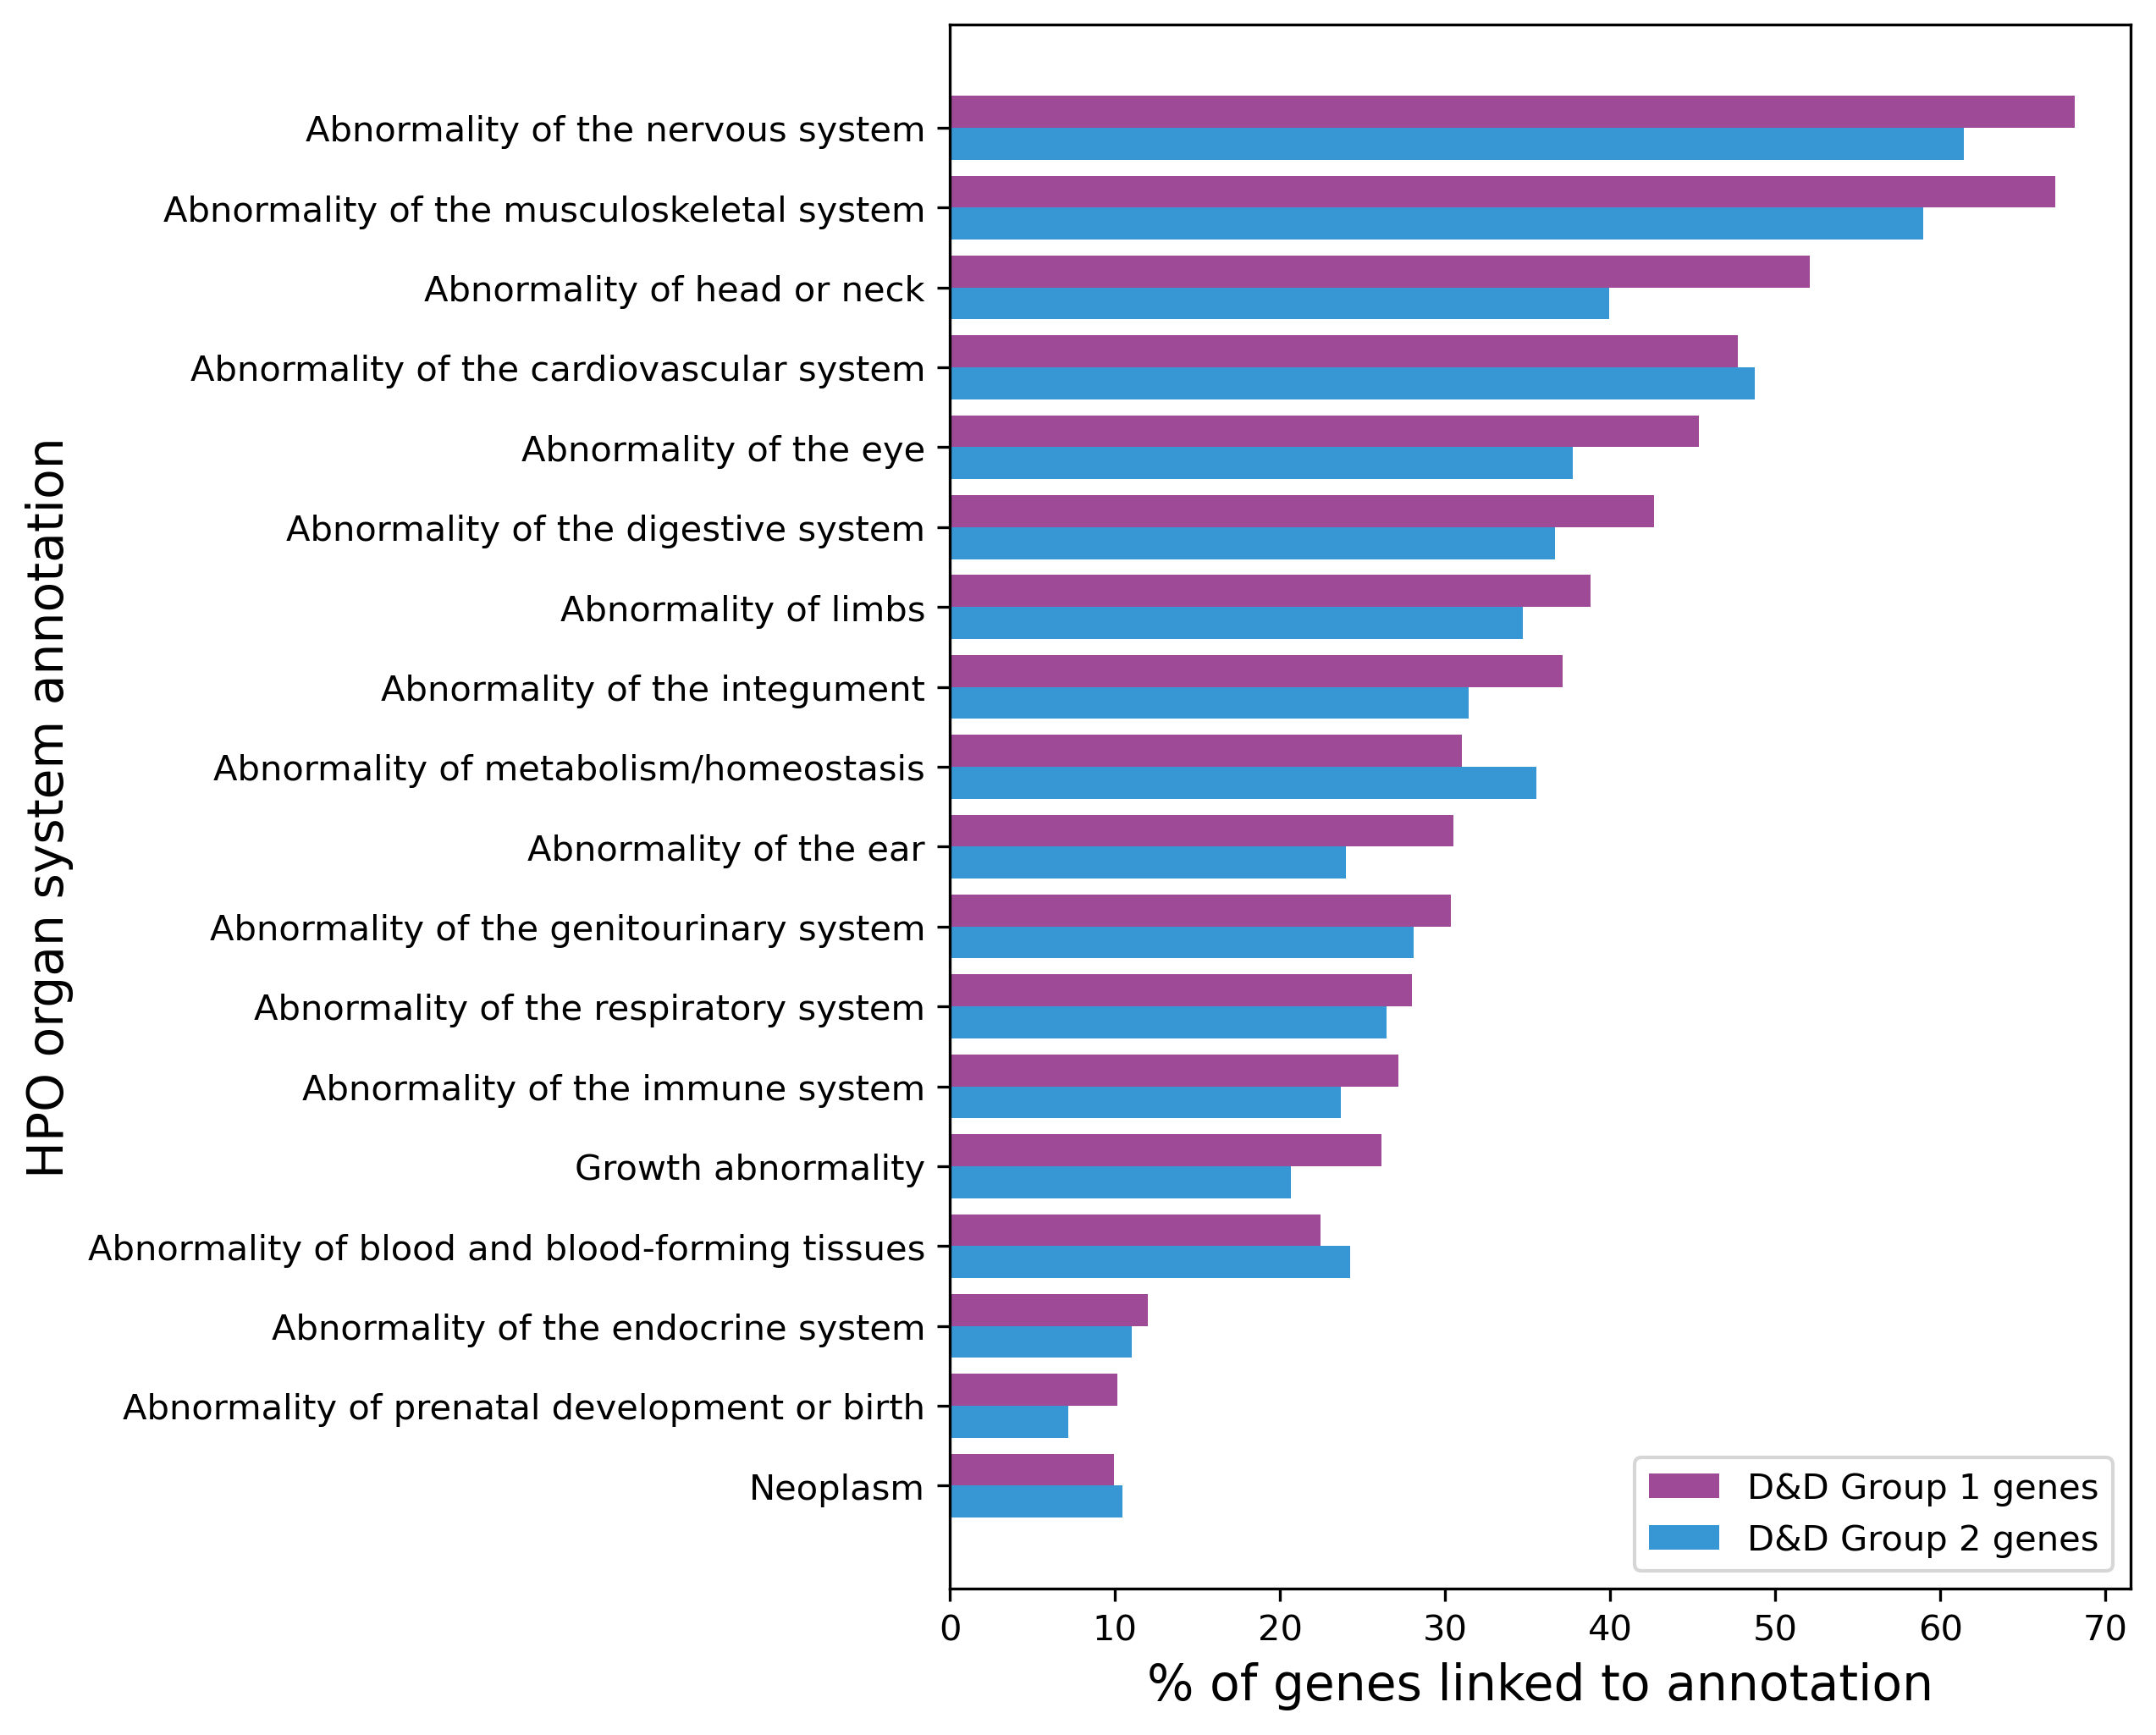

In [82]:
# isolate HPO data
hpo_data=data[['hgnc_symbol','HPO_terms','s_het']].drop_duplicates()

# get top level HPO terms
# hpo_file='../../data/hpo/hp.obo'
hpo_file='/Users/graceramey/Downloads/hp.obo'
graph = obonet.read_obo(hpo_file) # load HP ontology

def get_top_level_categories(hpo_id):
    """Return top-level HPO categories (direct children of HP:0000118)
    that are ancestors of the given HPO term."""
    if hpo_id not in graph:
        return []
    ancestors = nx.ancestors(graph.reverse(), hpo_id)
    # keep only ancestors that are direct children of ROOT_ID
    matches = [tid for tid in top_level_ids if tid in ancestors]
    return [(tid, top_level_terms[tid]) for tid in matches]

# we want to group HPO terms linked to each gene into larger organ system categories
# identify those broader organ system categories of interest here
ROOT_ID = "HP:0000118"  # Highest order term that we'll use: Phenotypic abnormality
top_level_ids = list(graph.predecessors(ROOT_ID))
top_level_terms = {
    t_id: graph.nodes[t_id]['name'] for t_id in top_level_ids
}

# tally up how many times each term occurs in the group 1 genes
term_df_g1 = pd.DataFrame({
    'term': list(top_level_terms.values()),
    'num_genes_w_term_g1':0
})

for idx,row in hpo_data.iterrows():
    cur_gene_terms = literal_eval(row.HPO_terms)
    for term in cur_gene_terms:
        # filter to the row of the data frame with the current term's name
        rows_with_term = term_df_g1[term_df_g1['term'] == term]
        # get index of this row
        row_index = list(rows_with_term.index)[0]
        # increment its value by 1
        cur_val = term_df_g1.loc[row_index, 'num_genes_w_term_g1']
        new_val = cur_val+1
        term_df_g1.loc[row_index, 'num_genes_w_term_g1'] = new_val

# do the same for genes that are in group two (s_het filter)
term_df_g2 = pd.DataFrame({
    'term': list(top_level_terms.values()),
    'num_genes_w_term_g2':0
})

g2_genes = list(hpo_data[hpo_data['s_het']<0.1]['hgnc_symbol'].unique())

for idx, row in hpo_data.iterrows():
    if row.hgnc_symbol in g2_genes:
        cur_gene_terms=literal_eval(row.HPO_terms)
        for term in cur_gene_terms:
            # filter to the row of the data frame with the current term's name
            rows_with_term = term_df_g2[term_df_g2['term'] == term]
            # get index of this row
            row_index = list(rows_with_term.index)[0]
            # increment its value by 1
            cur_val = term_df_g2.loc[row_index, 'num_genes_w_term_g2']
            new_val = cur_val+1
            term_df_g2.loc[row_index, 'num_genes_w_term_g2'] = new_val
# merge
term_df=term_df_g1.merge(term_df_g2, on='term', how='left')
# sort
term_df.sort_values(by=['num_genes_w_term_g1'], ascending=True, inplace=True, ignore_index=True)
# get percentages
term_df['g1_percent']=(term_df['num_genes_w_term_g1']/len(hpo_data['hgnc_symbol']))*100
term_df['g2_percent']=(term_df['num_genes_w_term_g2']/len(g2_genes))*100

# plot
num_genes_group1=len(list(set(hpo_data.hgnc_symbol)))
print(num_genes_group1)
num_genes_group2=len(g2_genes)
print(num_genes_group2)
plt.figure(figsize=(6, 8))

# remove a few categories from the visualization to make less clutered
temp_plot_df=term_df[~term_df['term'].isin(['Constitutional symptom','Abnormal cellular phenotype','Abnormality of the breast','Abnormality of the voice','Abnormality of the thoracic cavity'])]
temp_plot_df.reset_index(inplace=True, drop=True)

# numeric y positions
y = np.arange(len(temp_plot_df))
bar_height = 0.4

plt.barh(
    y + bar_height/2,
    (temp_plot_df['num_genes_w_term_g1'] / num_genes_group1) * 100,
    height=bar_height,
    color='#9f4a96',
    label='D&D Group 1 genes'
)

plt.barh(
    y - bar_height/2,
    (temp_plot_df['num_genes_w_term_g2'] / num_genes_group2) * 100,
    height=bar_height,
    color='#3697d4',
    label='D&D Group 2 genes'
)

plt.yticks(y, temp_plot_df['term'],fontsize=10)
plt.xlabel('% of genes linked to annotation', fontsize=14)
plt.ylabel('HPO organ system annotation',fontsize=14)
plt.legend()
plt.show()

## Figure 2A - Dominant Pathogenic Mutation Numbers/D&D Gene

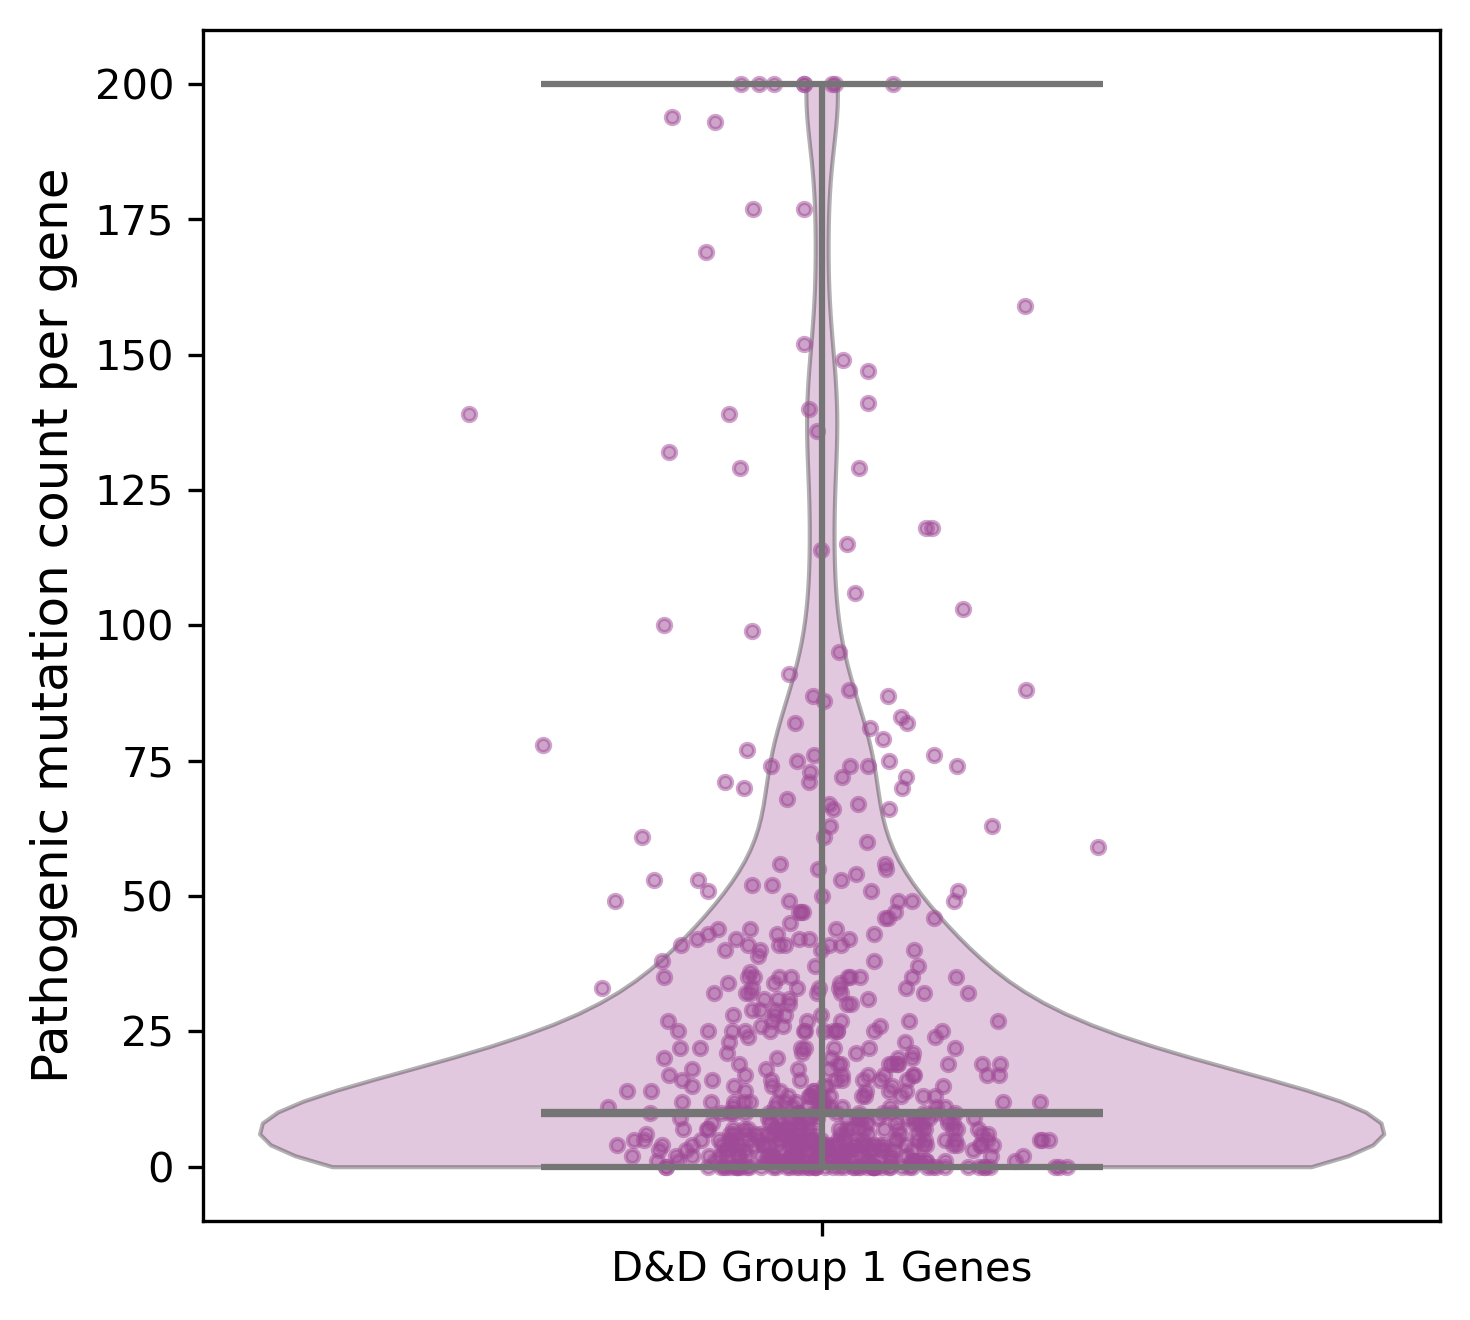

In [83]:
# isolate the column with the number of pathogenic/likely pathogenic mutations per gene
clinvar_data = data[['hgnc_symbol','dominant_mutation_count']].drop_duplicates()

# let's plot this now
cols = [
    "dominant_mutation_count"
]

# truncate points at 200
plot_data = [[x if x < 200 else 200 for x in clinvar_data["dominant_mutation_count"].values]]

fig, ax = plt.subplots(figsize=(5, 4.5))

vp = ax.violinplot(
    plot_data,
    showmeans=False,
    showmedians=True,
    showextrema=True
)

color_map=['#9f4a96']
for body, color in zip(vp["bodies"], color_map):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.3)

# Median
vp["cmedians"].set_color("#757575")
vp["cmedians"].set_linewidth(2)

# Extrema (min/max + connecting bar)
for key in ["cmins", "cmaxes", "cbars"]:
    vp[key].set_color("#757575")
    vp[key].set_linewidth(1.5)

ax.set_xticks(np.arange(1, len(plot_data) + 1))
ax.set_xticklabels(['D&D Group 1 Genes'], 
                   rotation=0)
color_map2 = ['#9f4a96']
for i, col in enumerate(plot_data, start=1):
    y = plot_data[i-1]
    x = np.random.normal(i, 0.04, size=len(y))  # jitter
    ax.scatter(x, y, s=10, alpha=0.5, color=color_map2[i-1])
ax.set_ylabel("Pathogenic mutation count per gene", fontsize=12)

plt.tight_layout()
plt.show()

## Figure 3A - Genes targetable by 1+ editing strategy

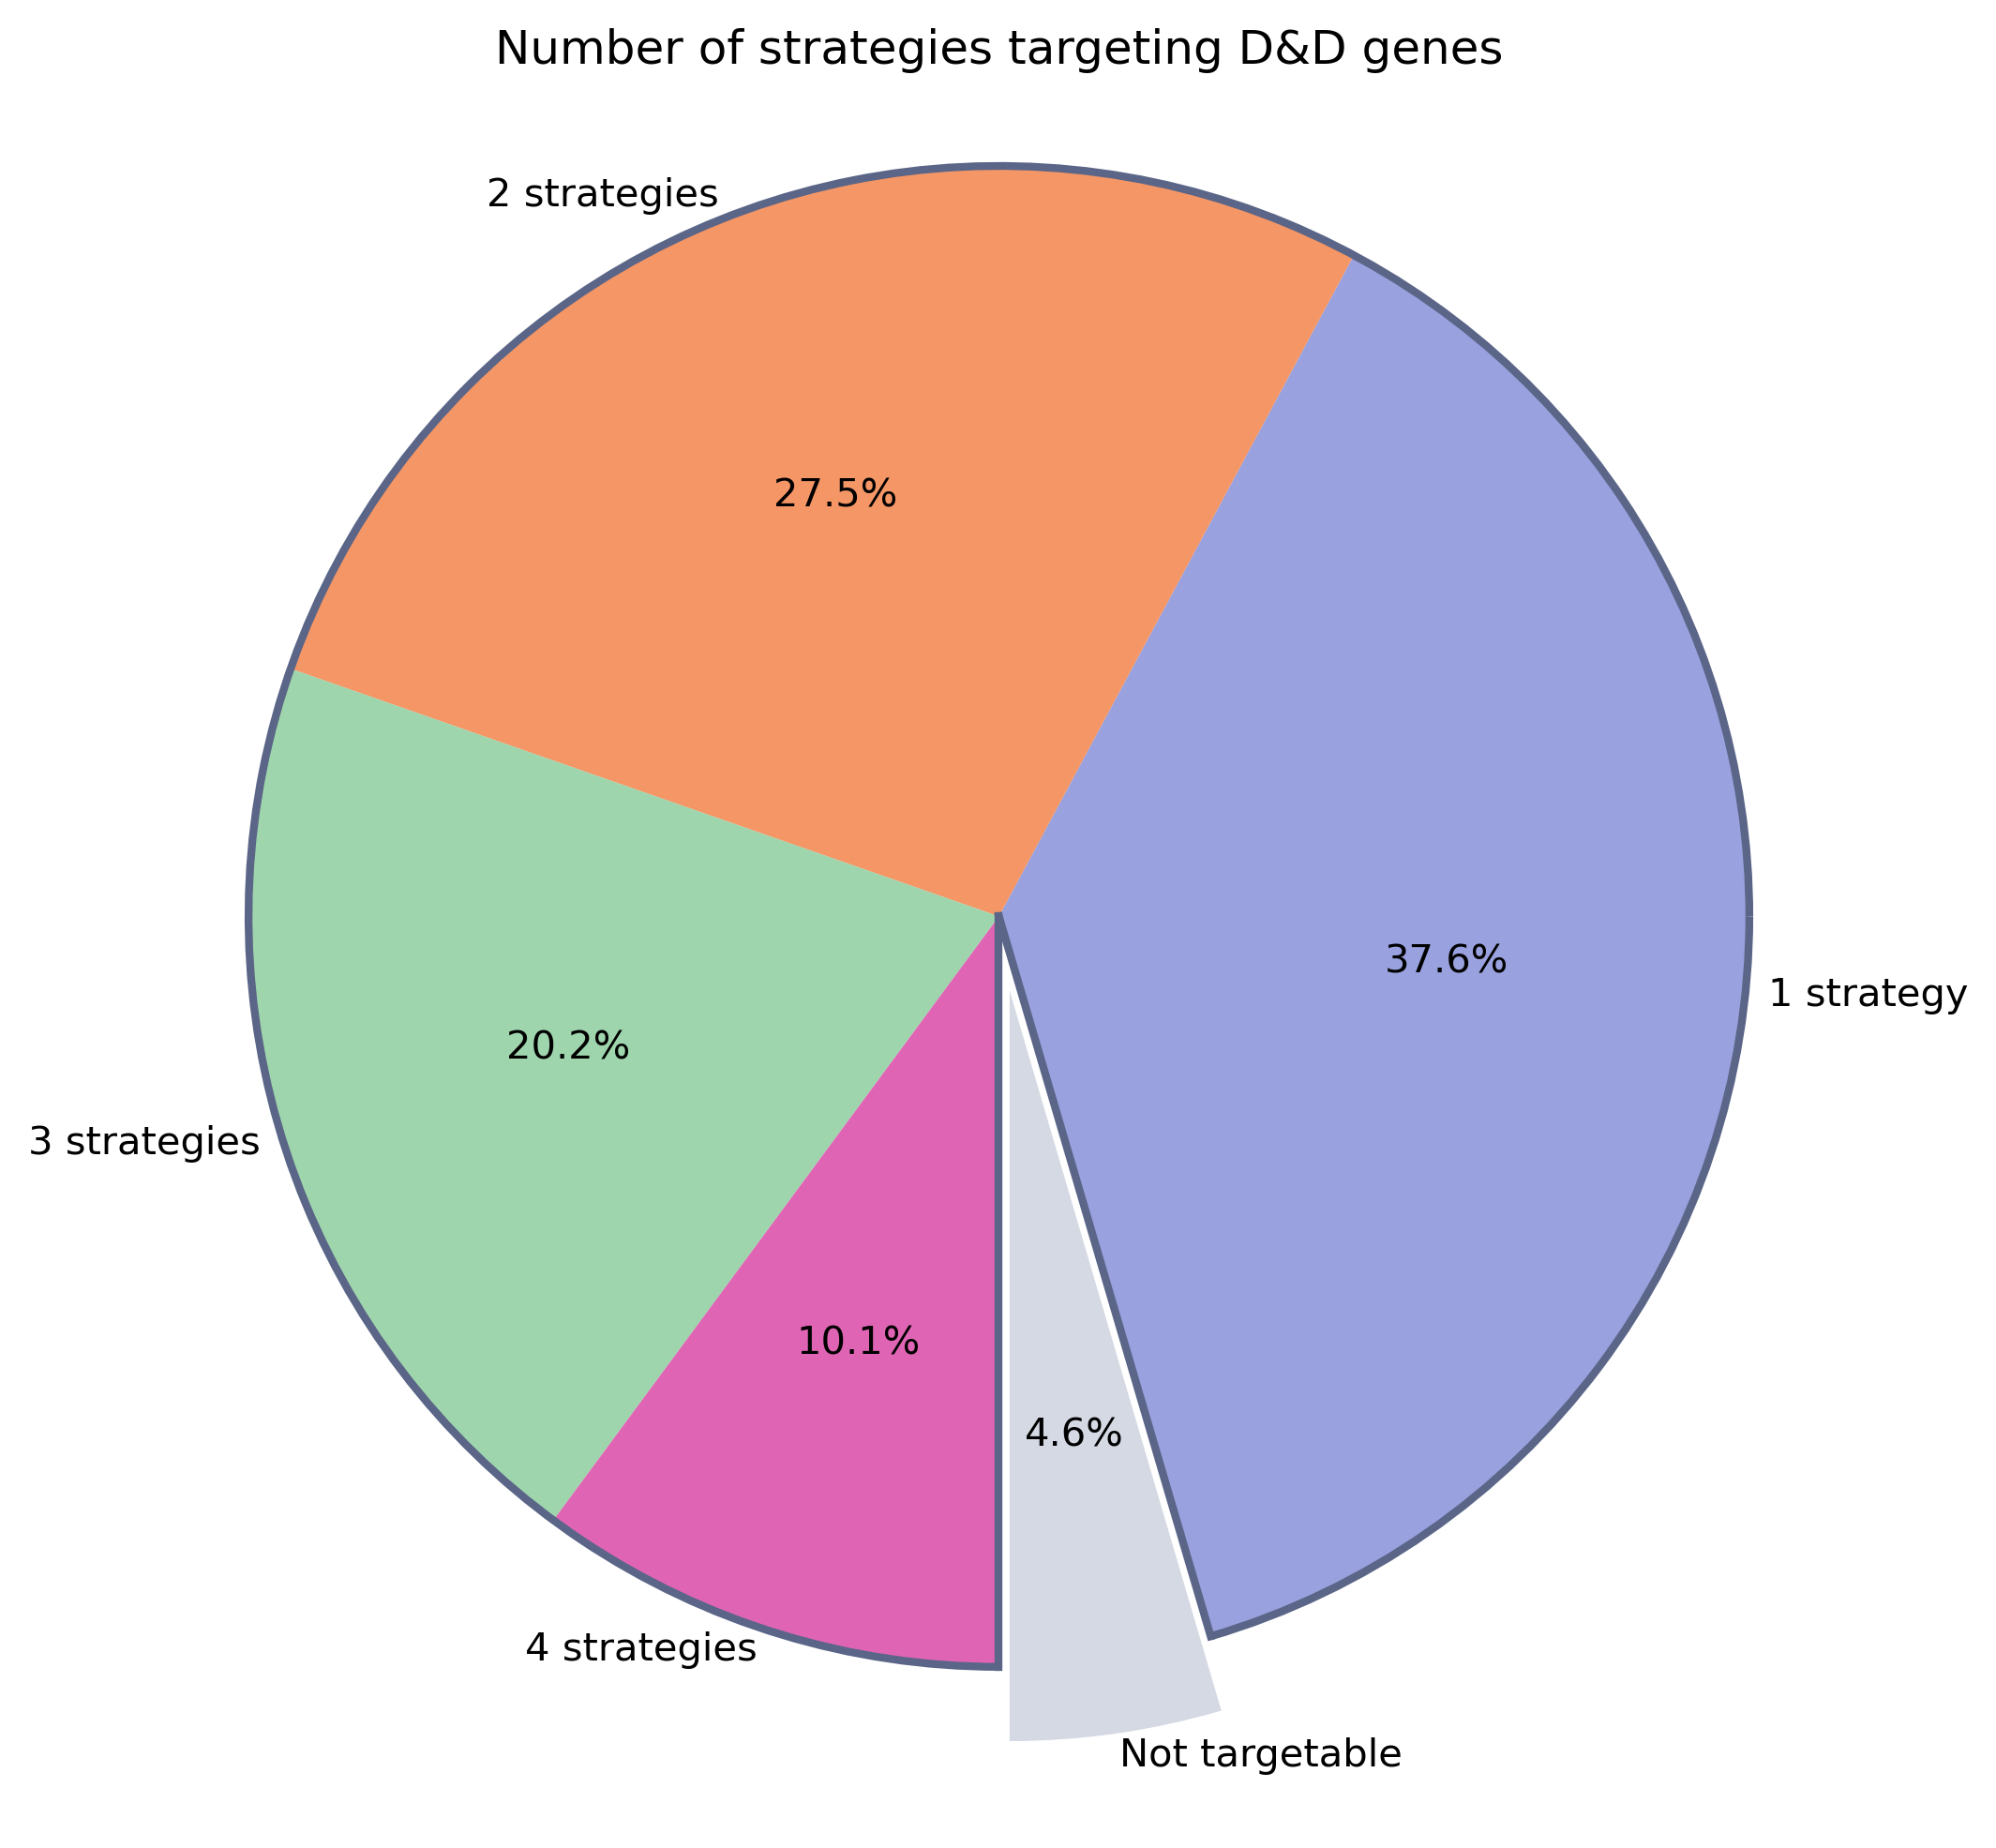

In [84]:
# isolate targetability data
target_data = data[['hgnc_symbol','exon_disr_targetable','epi_sil_targetable','ss_disr_targetable','excision_targetable']].drop_duplicates()
# find non-targetable genes
target_data['not_targetable']=[0 if x > 0 else 1 for x in target_data[['exon_disr_targetable','epi_sil_targetable','ss_disr_targetable','excision_targetable']].sum(axis=1)]
target_data['num_strats']=target_data[['exon_disr_targetable','epi_sil_targetable','ss_disr_targetable','excision_targetable']].sum(axis=1)

# get totals of each number
labels=[0,1,2,3,4]
labels2=['Not targetable', '1 strategy','2 strategies','3 strategies','4 strategies']
sizes=[]
for label in labels:
    sizes.append(len(target_data[target_data['num_strats']==label]['hgnc_symbol']))

import matplotlib.style as style
from matplotlib.patches import Wedge, Circle, Arc
from matplotlib.lines import Line2D
plt.figure(figsize=(8,8))
#style.use('tableau-colorblind10')
color_map={labels2[0]:'#C4C9D8', labels2[1]:'#7B85D4',labels2[2]:'#F37738',labels2[3]:'#82C995',labels2[4]:'#D7369E'}
color_map2=['#C4C9D8','#7B85D4','#F37738','#82C995','#D7369E']

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels2,
    autopct='%1.1f%%',
    startangle=270,
    colors=color_map2,
    labeldistance=1.03,
    explode=[0.1, 0, 0, 0, 0],
    wedgeprops=dict(edgecolor='none')
)

ax = plt.gca()

# ---- First wedge (Not targetable) angles ----
w0 = wedges[0]
theta_start = w0.theta1
theta_end = w0.theta2

lw = 2
radius = 1.0
diameter = 2 * radius

# ---- Outer arc excluding first wedge ----
arc1 = Arc(
    (0, 0),
    diameter, diameter,
    theta1=theta_end,
    theta2=360,
    linewidth=lw,
    color='#5A6587',
    zorder=3
)

arc2 = Arc(
    (0, 0),
    diameter, diameter,
    theta1=0,
    theta2=theta_start,
    linewidth=lw,
    color='#5A6587',
    zorder=3
)

ax.add_patch(arc1)
ax.add_patch(arc2)

# ---- Radial boundary lines at edges of first wedge ----
for theta in [theta_start, theta_end]:
    rad = np.deg2rad(theta)
    x = [0, radius * np.cos(rad)]
    y = [0, radius * np.sin(rad)]

    line = Line2D(
        x, y,
        linewidth=lw,
        color='#5A6587',
        zorder=3
    )
    ax.add_line(line)

# Example: fade "Not targetable" and "1 strategy"
opaque_labels = {'Not targetable'}

for wedge, label in zip(wedges, labels2):
    if label not in opaque_labels:
        wedge.set_alpha(0.77)
    else:
        wedge.set_alpha(0.7)
        
plt.axis('equal')
plt.title("Number of strategies targeting D&D genes")
plt.show()

## Figure 3C - Targetable Genes Across Edit Strategies

[ 4.55311973 26.98145025 35.58178752 40.80944351 90.38785835]
[ 27 160 211 242 536]


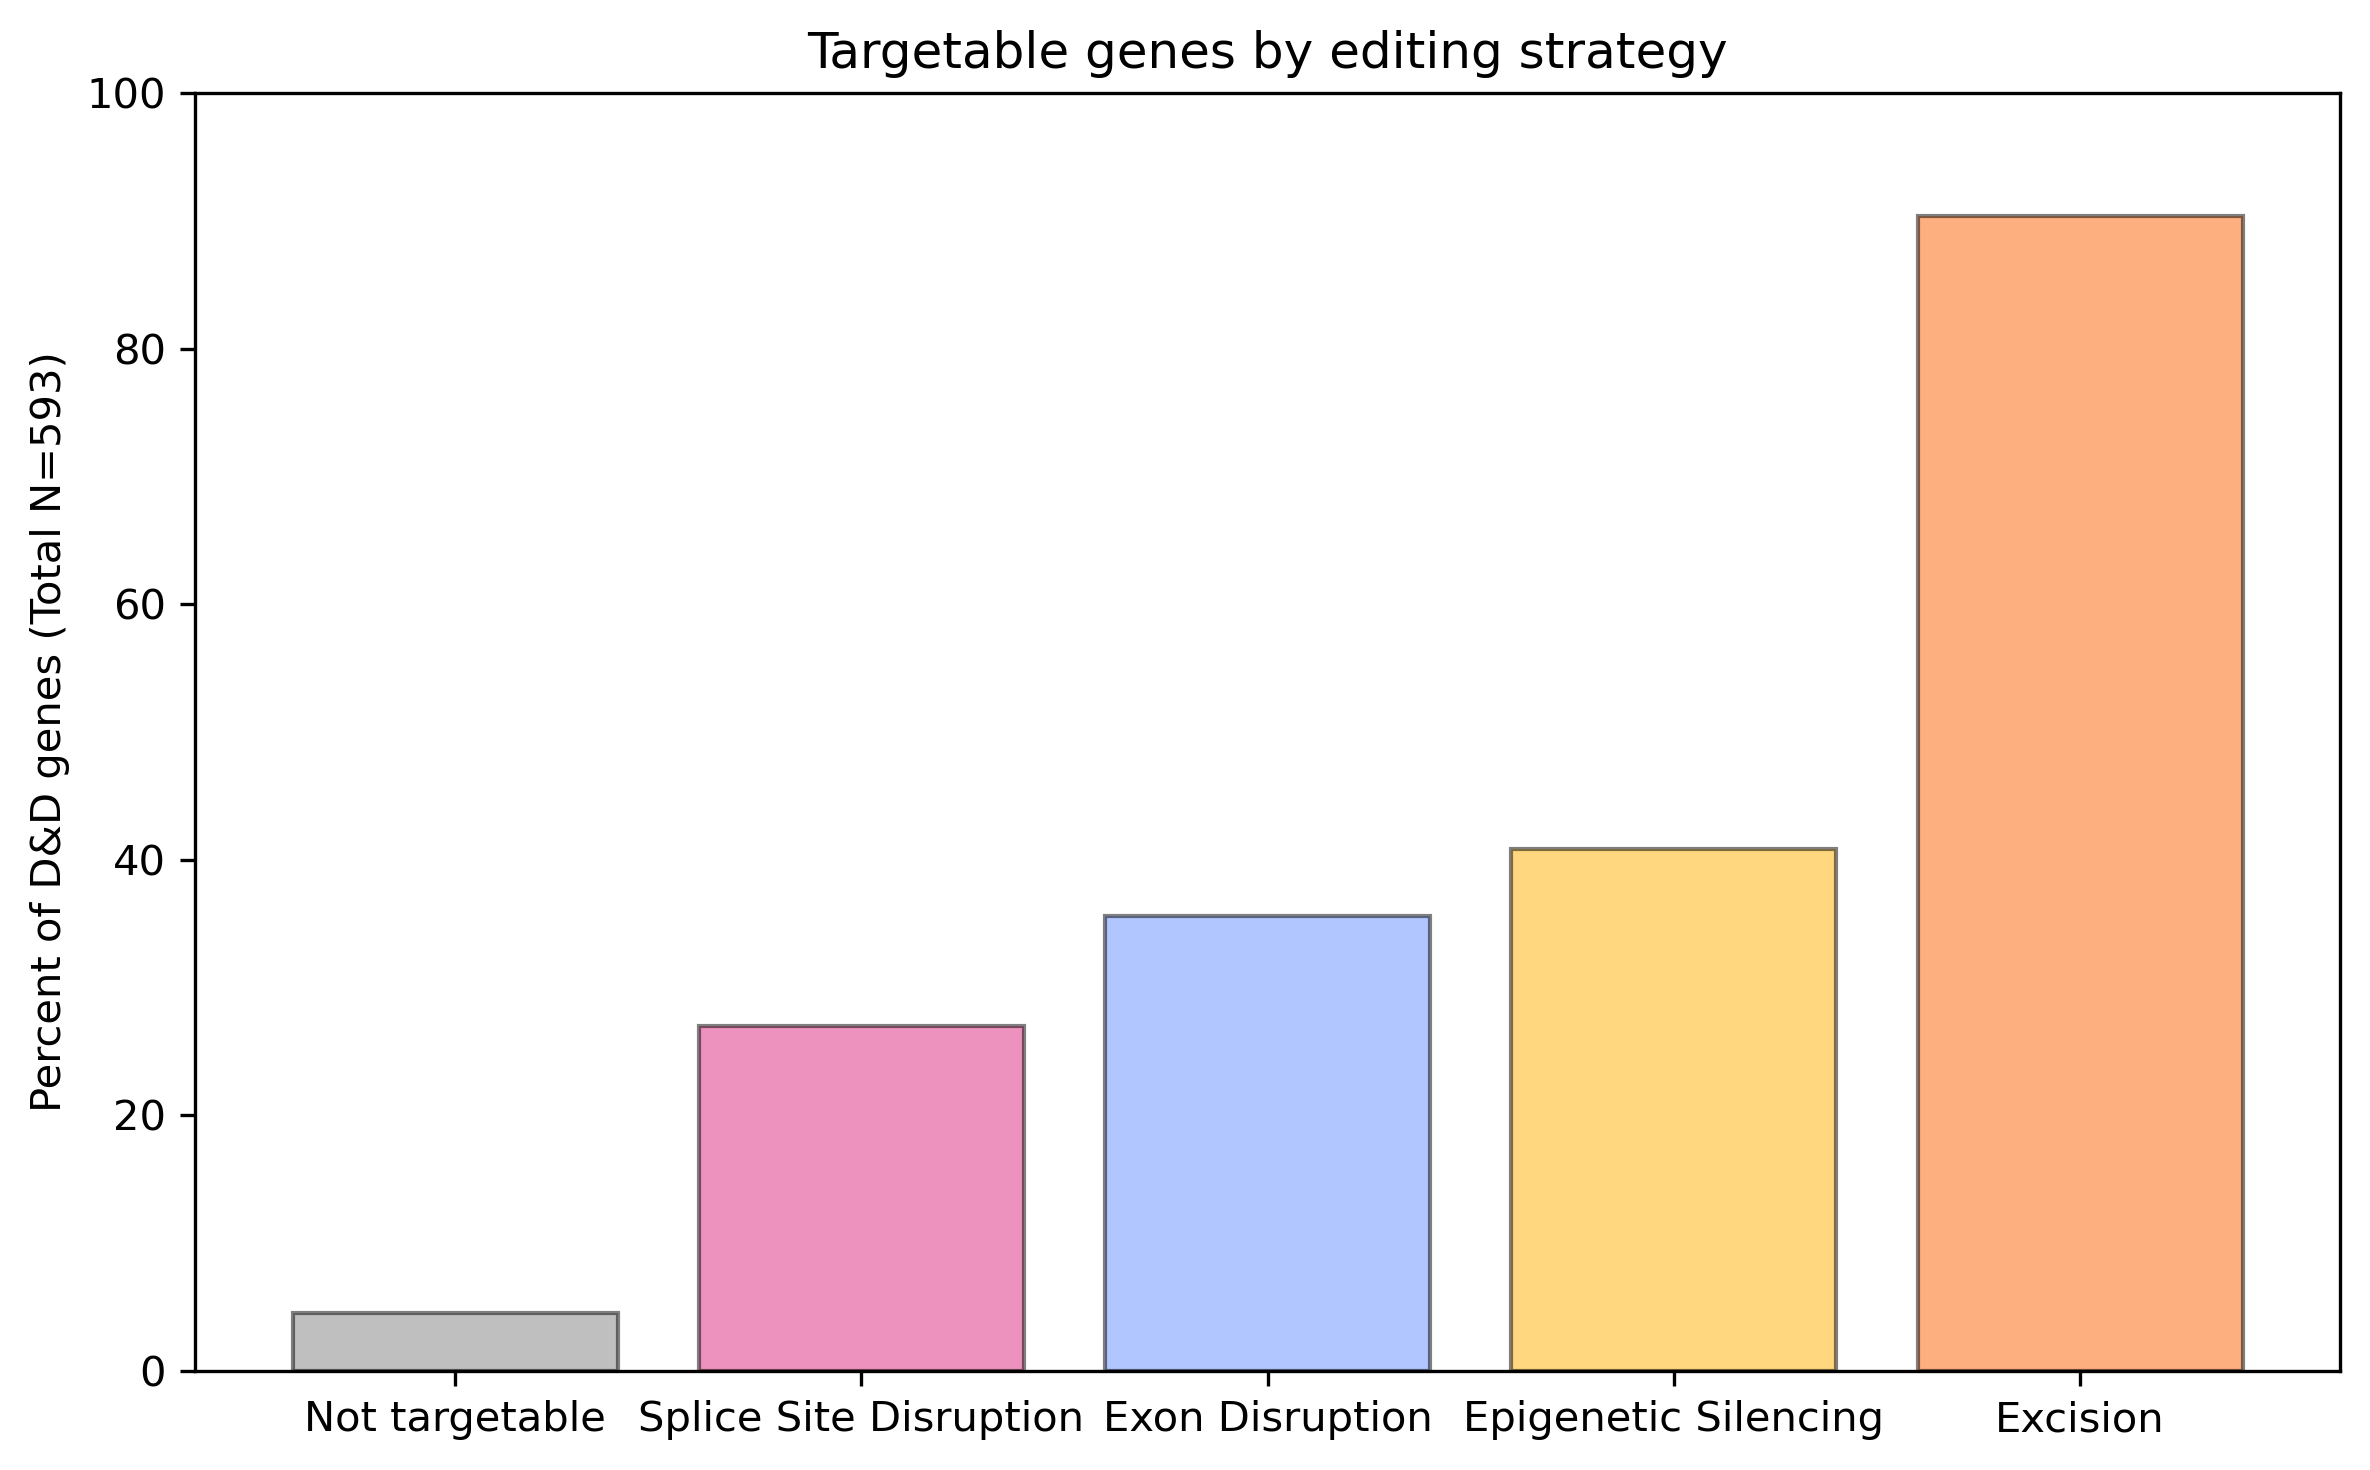

In [85]:
# use target data from before
methods = [
    "not_targetable",
    'ss_disr_targetable',
    'exon_disr_targetable',
    'epi_sil_targetable',
    'excision_targetable'
]

counts = target_data[methods].sum()
labels = [
    "Not targetable",
    "Splice Site Disruption",
    "Exon Disruption",
    "Epigenetic Silencing",
    "Excision",
    
]
print((counts.values/len(target_data))*100)
print(counts.values)
color_map=['grey', '#DC267F', '#648FFF','#FFB000','#FE6100']
fig = plt.figure(figsize=(8, 5))
plt.bar(labels, (counts.values/len(target_data))*100, color=color_map, alpha=0.5, edgecolor="black")
plt.ylabel("Percent of D&D genes (Total N=593)")
plt.ylim((0,100))
plt.title("Targetable genes by editing strategy")
plt.tight_layout()
plt.show()

## Figure 3D - Targetable Common Variant Numbers Across Genes

In [ ]:
# isolate common variant numbers
cv_data = data[['hgnc_symbol', 'num_exon_disr_vars', 'num_epi_sil_vars', 'num_ss_disr_vars', 'num_excision_vars']].drop_duplicates()
# fill NAs with 0
cv_data.fillna(0,inplace=True)

# get the unique snps across genes
filenames=['../../results/indels/NMD/CommonVars/NMD_induction_var_info.csv',
           '../../results/CRISPRoff/CommonVars/CommonVars_ALL_dict.pkl',
           '../../results/acceptor_base_edits/CommonVars/CommonVars_ALL_dict.pkl',
           '../../results/donor_base_edits/CommonVars/CommonVars_ALL_dict.pkl',
           '../../results/excision/CommonVars/refined_common_vars/ALLgene_refined_snps.pkl']
# load the variant files
covar_dicts=[]
for file in filenames:
    if 'NMD' in file:
        indel_csv = pd.read_csv(file)
    else:
        with open(file, 'rb') as fp:
            covar_dicts.append(pickle.load(fp))
# merge information across edit strategies
from ast import literal_eval
overall_gene_vars={}
for gene in df['hgnc_symbol'].unique():
    cur_gene_vars=set()
    for d in covar_dicts:
        if gene in list(d.keys()):
            cur_strat_gene_vars = d[gene]
            # add var locs to set while taking exceptions into account
            cur_gene_vars.update(
                x[0]
                for x in cur_strat_gene_vars
                if isinstance(x, list) and len(x) == 2
            )
    if gene in indel_csv.gene.values:
        filt_df = indel_csv[indel_csv['gene']==gene]
        NMD_passing_indel_vars = literal_eval(filt_df.vars_consistently_inducing_NMD.values[0])
        if isinstance(NMD_passing_indel_vars, (list, set, tuple)):
            cur_gene_vars.update(NMD_passing_indel_vars)
        elif NMD_passing_indel_vars is not None:
            cur_gene_vars.add(NMD_passing_indel_vars)
    overall_gene_vars[gene]=cur_gene_vars
# finally, get the unique snps from these merged files
unique_snps = [len(x) for x in list(overall_gene_vars.values())]

# plot below
# --- Prepare data ---
group1 = cv_data[cv_data['num_exon_disr_vars'] > 0]['num_exon_disr_vars']
group2 = cv_data[cv_data['num_epi_sil_vars'] > 0]['num_epi_sil_vars']
group3 = cv_data[cv_data['num_ss_disr_vars'] > 0]['num_ss_disr_vars']
group4 = cv_data[cv_data['num_excision_vars'] > 0]['num_excision_vars']
group5 = [x for x in unique_snps if x > 0]

plot_data = [group3, group1, group2, group4, group5] # we want these in a specific order, which is why things look a bit wonky here

labels = ["Splice Site Disruption", "Exon Disruption", "Epigenetic Silencing", "Excision", "All Strategies"]
color_map = ['#DC267F', '#648FFF', '#FFB000', '#FE6100', 'white']

# --- Figure ---
fig, ax = plt.subplots(figsize=(8, 7.5))

# --- Violin layer (distribution only) ---
vp = ax.violinplot(
    plot_data,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body, color in zip(vp["bodies"], color_map):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.35)
    body.set_linewidth(1)

# --- Boxplot overlay (IQR + Tukey whiskers) ---
bp = ax.boxplot(
    plot_data,
    widths=0.05,
    patch_artist=True,
    showfliers=False,
    whis=1.5  # Tukey whiskers (1.5 × IQR),
    # showmeans=True,
    # meanline=True
)

# Style IQR box
for box in bp['boxes']:
    box.set(facecolor='#EAEBEB', edgecolor='black', linewidth=1)

# Style median
for median in bp['medians']:
    #median.set_visible(False)
    median.set(color='black', linewidth=1)

# for mean in bp['means']:
#     mean.set(color='black', linewidth=1.5)

# Style whiskers and caps
for whisker in bp['whiskers']:
    whisker.set(color='black', linewidth=1.2)

for cap in bp['caps']:
    cap.set_visible(False)

# --- Axes formatting ---
ax.set_xticks(range(1, 6))
ax.set_xticklabels(labels, fontsize=11)

ax.set_ylabel("Number of common variants per gene", fontsize=12)
ax.set_title("Common Variants Targetable by Strategy in Each D&D Gene",
             fontsize=13, pad=10)

ax.set_yscale("log")

# Clean spines (publication style)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis='both', which='major', labelsize=10, width=1)

plt.tight_layout()
plt.show()

## Figure 3E - Upset Plot of Genes per Different Strategy Combinations

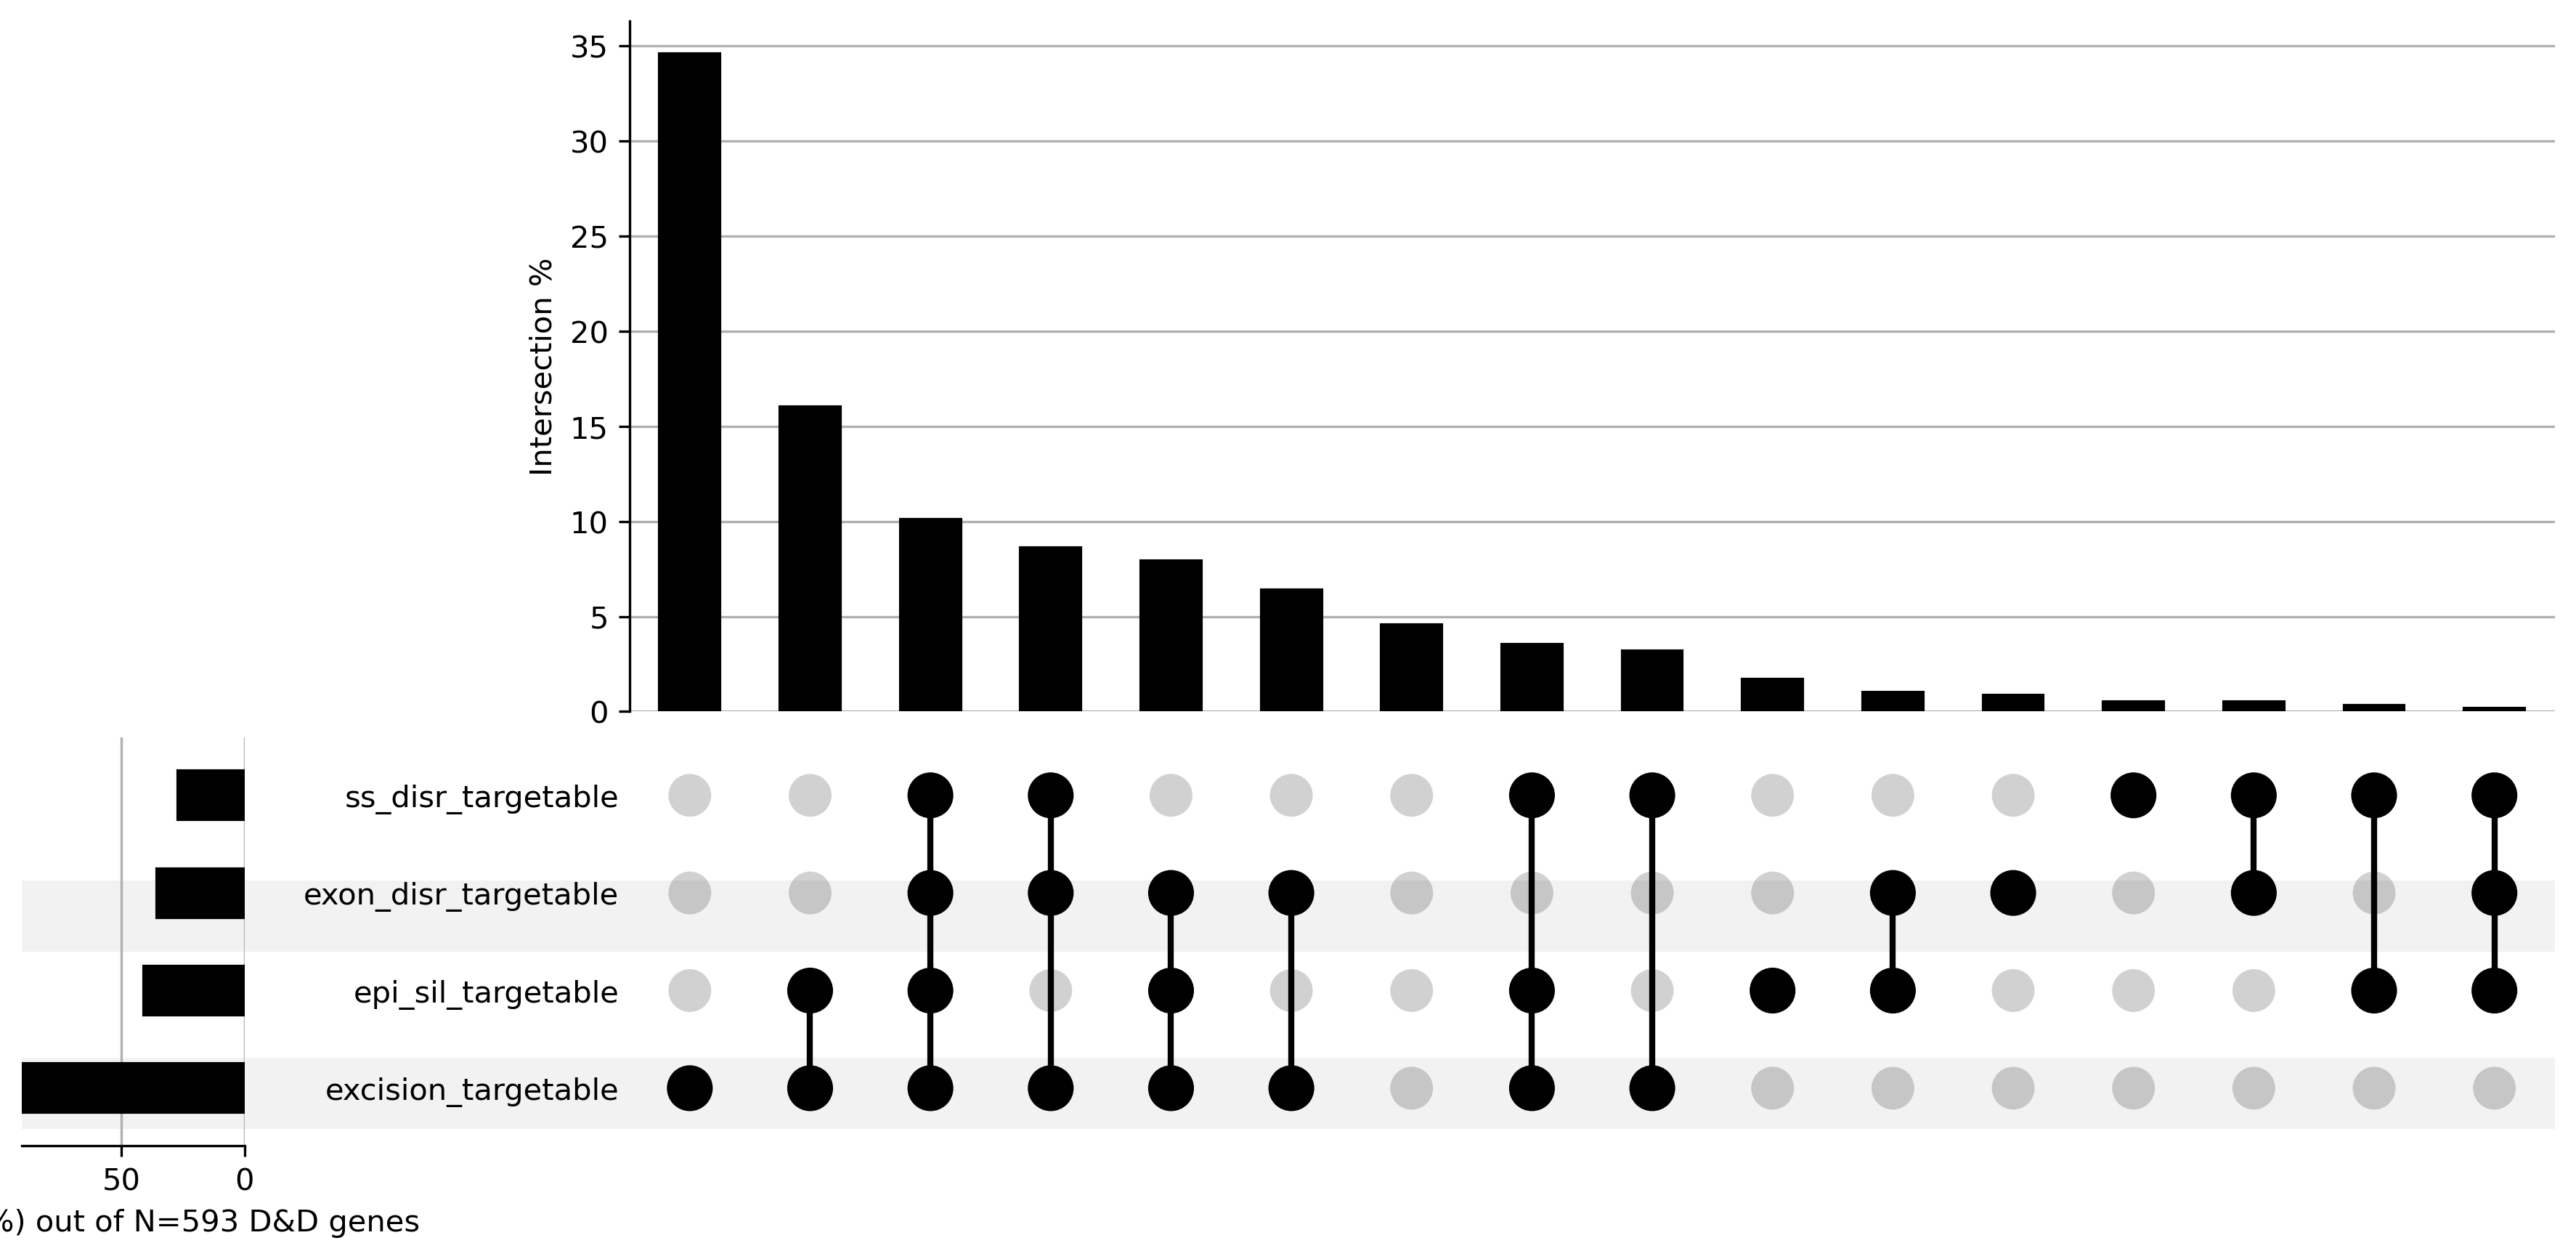

In [87]:
# use target data again
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    upset_data = target_data[['ss_disr_targetable',
    'exon_disr_targetable',
    'epi_sil_targetable',
    'excision_targetable']]
    upset_bool = upset_data.astype(bool)
    
    df_up = upset_bool.groupby(list(upset_data.columns)).size()
    df_up_percent = (df_up / df_up.sum()) * 100

    fig = plt.figure(figsize=(15, 6))
    plot_result = plot(df_up_percent, fig=fig, element_size=None, sort_by='cardinality')

    ax_intersections = plot_result["intersections"]
    ax_totals = plot_result["totals"]
    ax_matrix = plot_result["matrix"]

    # -----------------------------
    # Slightly increase bottom matrix height (~1.1×)
    # -----------------------------
    pos_matrix = ax_matrix.get_position()
    ax_matrix.set_position([
        pos_matrix.x0,
        pos_matrix.y0,
        pos_matrix.width,
        pos_matrix.height * 1.1  # just a tiny bit bigger
    ])

    # Shift intersection bars up accordingly
    pos_intersections = ax_intersections.get_position()
    ax_intersections.set_position([
        pos_intersections.x0,
        pos_matrix.y0 + ax_matrix.get_position().height + 0.02,
        pos_intersections.width,
        1 - (pos_matrix.y0 + ax_matrix.get_position().height + 0.05)
    ])

    # Align totals axis with matrix height
    pos_totals = ax_totals.get_position()
    ax_totals.set_position([
        pos_totals.x0,
        pos_matrix.y0,
        pos_totals.width,
        ax_matrix.get_position().height
    ])

    # -----------------------------
    # Labels and styling
    # -----------------------------
    ax_totals.set_xlabel("Set size (%) out of N=593 D&D genes")
    ax_intersections.set_ylabel("Intersection %")
    ax_totals.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

# Figure 4B - People targetable by at least one strategy

In [88]:

data.columns

Index(['hgnc_symbol', 'Gene_Group', 'GENE ID (HGNC)', 'DISEASE LABEL',
       'DISEASE ID (MONDO)', 'MOI', 'CLASSIFICATION',
       'dominant_mutation_count', 'HPO_terms', 'HI Score', '%HI', 'pLI',
       'LOEUF', 'ensg', 'chrom', 'obs_lof', 'exp_lof', 's_het',
       's_het_lower_95', 's_het_upper_95', 'exon_disr_targetable',
       'num_exon_disr_vars', 'epi_sil_targetable', 'num_epi_sil_vars',
       'ss_disr_targetable', 'num_ss_disr_vars', 'excision_targetable',
       'num_excision_vars', 'num_excision_pairs', 'num_hets_preCas_all_strats',
       'prop_hets_preCas_all_strats', 'num_hets_preCas_exon_disr',
       'prop_hets_preCas_exon_disr', 'num_hets_preCas_epi_sil',
       'prop_hets_preCas_epi_sil', 'num_hets_preCas_ss_disr',
       'prop_hets_preCas_ss_disr', 'num_hets_preCas_excision',
       'prop_hets_preCas_excision', 'exon_disr_spcas9_targetable',
       'epi_sil_spcas9_targetable', 'ss_disr_spcas9_targetable',
       'excision_spcas9_targetable', 'num_hets_all_strats',


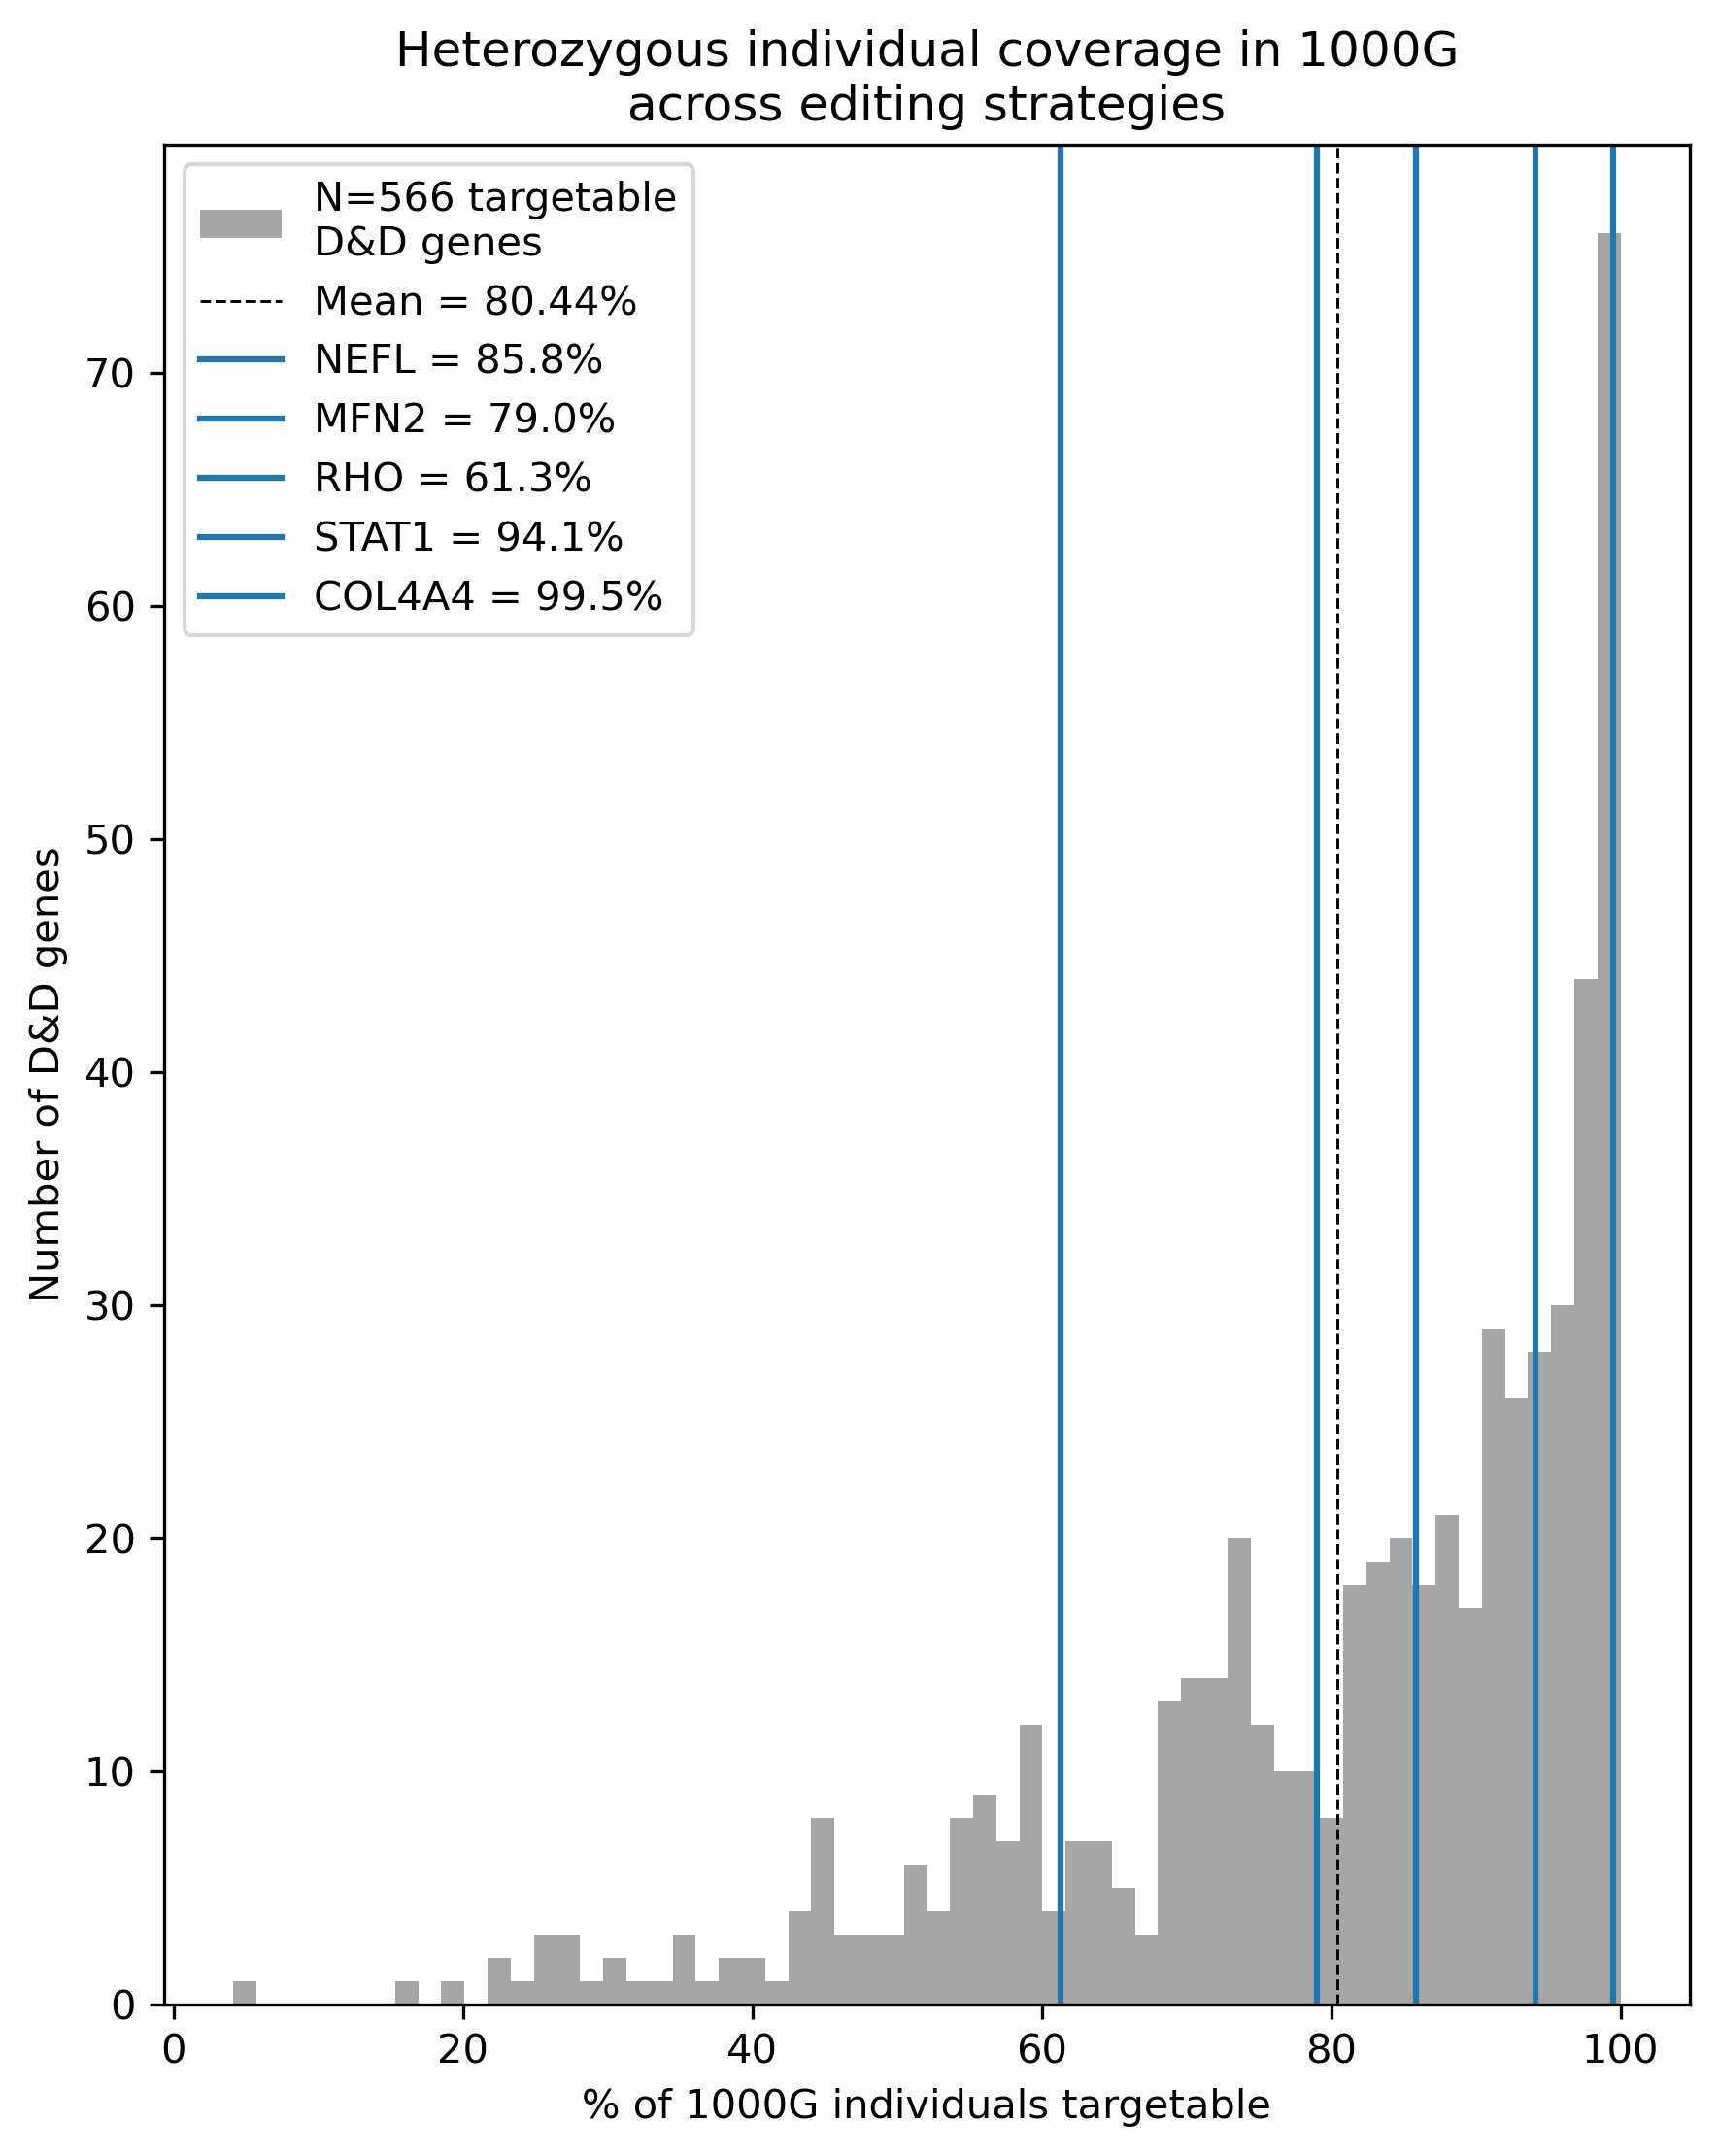

In [89]:
# isolate heterozygous individual information
het_data = data[['hgnc_symbol','prop_hets_preCas_all_strats']].drop_duplicates()
het_data=het_data.merge(target_data[['hgnc_symbol','not_targetable']], on='hgnc_symbol', how='left')
df_targetable = het_data[het_data['not_targetable']==0]
# now plot this information
plt.figure(figsize=(6, 7.5))
num_genes=len(df_targetable['hgnc_symbol'])
plot_data=df_targetable['prop_hets_preCas_all_strats']*100
plt.hist(plot_data,bins=60,color='grey',density=False,label='N=' + str(num_genes) + ' targetable\nD&D genes', alpha=0.7)

from scipy.stats import gaussian_kde

# Calculate the KDE
kde = gaussian_kde(plot_data)

# Generate points for the smooth curve
x_vals = np.linspace(min(plot_data), max(plot_data), 1000)
kde_vals = kde(x_vals)

# Plot the KDE smooth curve
mean_value = plot_data.mean()
plt.axvline(mean_value, color='black', linestyle='--', linewidth=0.7,
            label=f"Mean = {mean_value:.2f}%")

genes_to_highlight = ['NEFL','MFN2','RHO','STAT1','COL4A4']

for gene in genes_to_highlight:
    gene_value = (
        df_targetable.loc[
            df_targetable['hgnc_symbol'] == gene,
            'prop_hets_preCas_all_strats'
        ].values[0] * 100
    )
    
    plt.axvline(
        gene_value,
        linestyle='-',
        linewidth=1.5,
        label=f"{gene} = {gene_value:.1f}%"
    )
    
#plt.plot(x_vals, kde_vals, color='red', linestyle='-', linewidth=2, alpha=0.5)
plt.ylabel('Number of D&D genes')
plt.xlabel('% of 1000G individuals targetable')
plt.title('Heterozygous individual coverage in 1000G\nacross editing strategies')
plt.legend()
plt.tight_layout()
plt.show()

## Figure 5A - MYH7 Exon Disruption

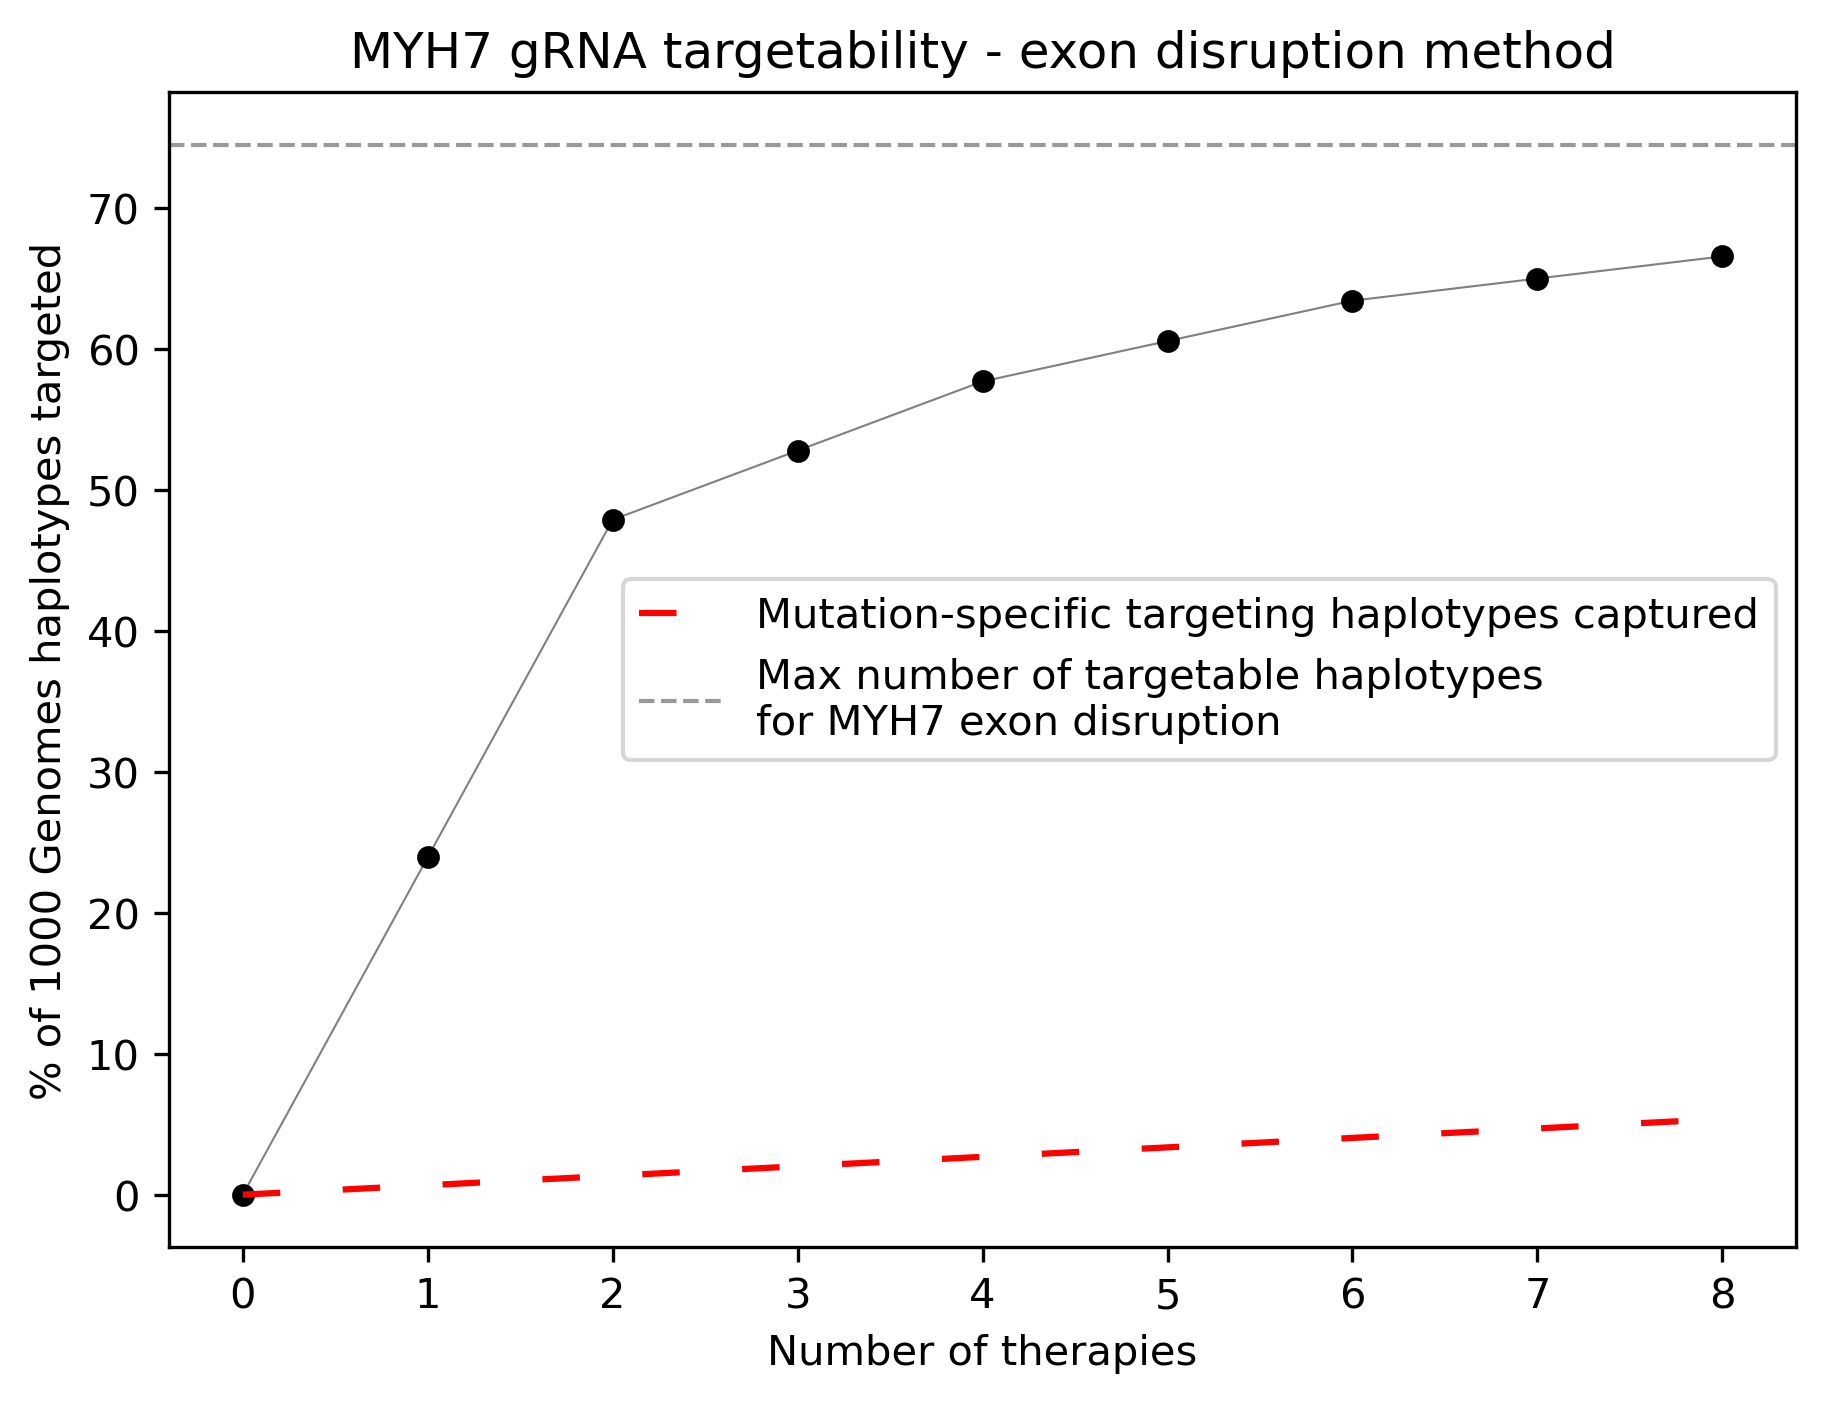

In [90]:
# MYH7 Data
myh7_df = pd.DataFrame({
    "snp1_allele": [
        "23433544_0","23433544_1","23429785_0","23429785_1",
        "23431585_0","23431585_1","23415680_0","23415680_1"
    ],
    "snp2_allele": [""]*8,
    "haplotypes_added": [1220,1220,250,250,146,146,80,80],
    "people_added": [0,1220,0,250,0,146,0,80],
    "cumulative_haplotypes_targeted": [1220,2440,2690,2940,3086,3232,3312,3392],
    "cumulative_people_targeted": [0,1220,1220,1470,1470,1616,1616,1696],
    "num_guides": [1,2,3,4,5,6,7,8]
})

# add a row for '0 guides'
new_row = {
    'snp1_allele': None,
    'snp2_allele': None,
    'haplotypes_added': 0,
    'people_added': 0,
    'cumulative_haplotypes_targeted': 0,
    'cumulative_people_targeted': 0,
    'num_guides': 0
}
myh7_df = pd.concat([myh7_df, pd.DataFrame([new_row])], ignore_index=True)
myh7_df.sort_values(inplace=True, by='num_guides', ascending=True, ignore_index=True)

# plot below
plt.figure(figsize=(7, 5))
# plot mutation-specific targeting line
x = myh7_df['num_guides']
y=[]
for item in myh7_df['num_guides']:
    # for each item, we'll be able to treat item/149 of the haplotype population at that stage, since there are 149 pathogenic mutations for MYH7
    y.append(((item/149)*100))
plt.plot(x, y, color='red', linestyle='--', label='Mutation-specific targeting haplotypes captured', dashes=(6, 10))

plt.axhline(
    y=0.744898*100, # max number of haplotypes targetable by excision for fus
    linestyle='--',
    linewidth=1,
    alpha=0.8,
    color='grey',
    label='Max number of targetable haplotypes\nfor MYH7 exon disruption'
)
plt.plot(
    myh7_df['num_guides'],
    100 * myh7_df['cumulative_haplotypes_targeted'] / (2548*2),
    color='grey',
    linewidth=0.5,
    zorder=1
)
plt.scatter(myh7_df['num_guides'], 100*myh7_df['cumulative_haplotypes_targeted']/(2548*2),color='black', s=20)

plt.xlabel('Number of therapies')
plt.ylabel('% of 1000 Genomes haplotypes targeted')
plt.title('MYH7 gRNA targetability - exon disruption method')
plt.legend()
plt.show()

## Figure 5B - % total haplotypes captured by 4 gRNAs

/var/folders/d8/m8_nz4tx72l143cvq_1skt6h0000gn/T/ipykernel_31938/1786040432.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('Nan', np.nan)


Splice Site Disruption – Possible targetable hets | n=160 | mean=40.58% | median=38.99%
Splice Site Disruption – Targetable hets
with top four therapies | n=134 | mean=38.36% | median=37.38%
Exon Disruption – Possible targetable hets | n=211 | mean=43.96% | median=43.45%
Exon Disruption – Targetable hets
with top four therapies | n=190 | mean=41.06% | median=42.27%
Epigenetic Silencing – Possible targetable hets | n=242 | mean=42.48% | median=42.72%
Epigenetic Silencing – Targetable hets
with top four therapies | n=223 | mean=40.78% | median=41.99%
Excision – Possible targetable hets | n=536 | mean=81.95% | median=87.19%
Excision – Targetable hets
with top four therapies | n=535 | mean=38.85% | median=40.66%


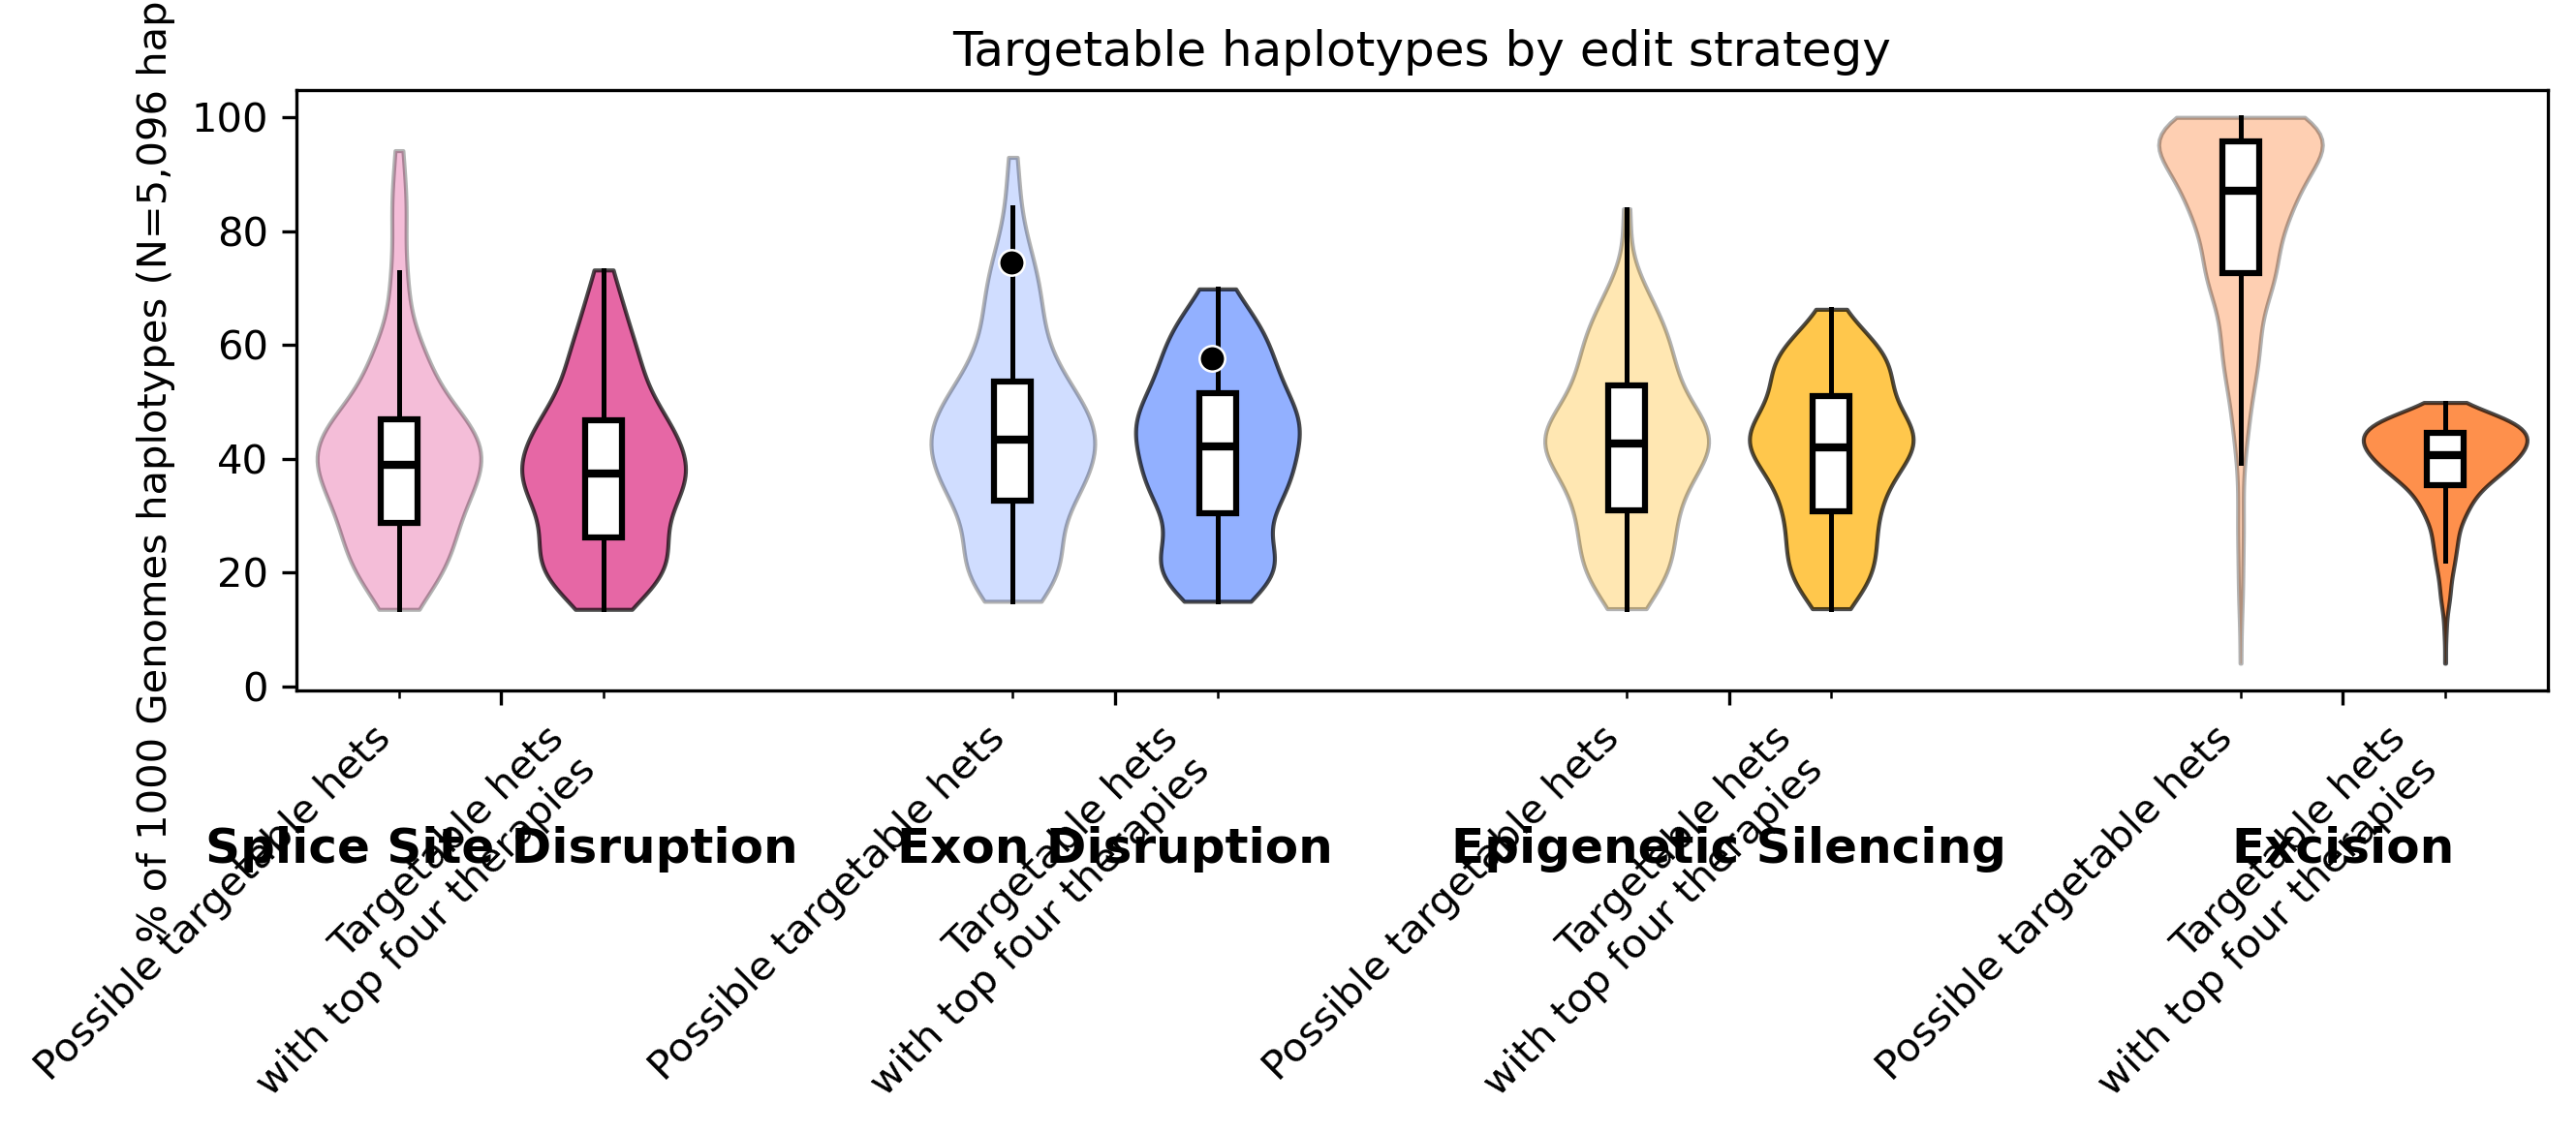

In [93]:
# isolate haplotype information
df = data[[
    'hgnc_symbol',
    'num_hets_preCas_exon_disr','num_hets_preCas_epi_sil','num_hets_preCas_ss_disr','num_hets_preCas_excision',
    'num_hets_exon_disr', 'num_hets_epi_sil','num_hets_ss_disr','num_hets_excision',
    'num_haplos_targeted_ag_exon_disr', 'num_haplos_targeted_ag_epi_sil','num_haplos_targeted_ag_ss_disr','num_haplos_targeted_ag_excision',
    'num_haplos_targeted_4g_exon_disr', 'num_haplos_targeted_4g_epi_sil', 'num_haplos_targeted_4g_ss_disr', 'num_haplos_targeted_4g_excision'
]].drop_duplicates()
# replace zeroes with Nans
df = df.replace(0, np.nan)
df = df.replace('Nan', np.nan)

# --- Settings ---
color_map = ['#DC267F', '#648FFF', '#FFB000', '#FE6100']
shade_levels = [0.3, 0.7]  # opacity for stage 0 and stage 1

strategies = {
    "Splice Site Disruption": ['num_hets_preCas_ss_disr', 'num_haplos_targeted_4g_ss_disr'],
    "Exon Disruption": ['num_hets_preCas_exon_disr', 'num_haplos_targeted_4g_exon_disr'],
    "Epigenetic Silencing": ['num_hets_preCas_epi_sil', 'num_haplos_targeted_4g_epi_sil'],
    "Excision": ['num_hets_preCas_excision', 'num_haplos_targeted_4g_excision'],
}

stage_labels = ["Possible targetable hets", "Targetable hets\nwith top four therapies"]
total_haplotypes = 5096
group_spacing = 3
violin_spacing = 1

# --- Prepare data ---
positions = []
plot_data = []
group_index = []
within_group_index = []
column_names = []

for i, (strategy, cols) in enumerate(strategies.items()):
    base_pos = i * group_spacing
    for j, col in enumerate(cols):
        values = df[col].dropna()

        # Convert het counts to haplotypes
        if "num_" in col and "_hets" in col:
            values = values * 2

        # Convert to percent
        values = values / total_haplotypes * 100

        if len(values) == 0:
            continue

        print(f"{strategy} – {stage_labels[j]} | n={len(values)} | mean={values.mean():.2f}% | median={values.median():.2f}%")

        plot_data.append(values)
        positions.append(base_pos + j * violin_spacing)
        group_index.append(i)
        within_group_index.append(j)
        column_names.append(col)

# --- Create figure ---
fig, ax = plt.subplots(figsize=(9, 4))

# --- Draw violins ---
parts = ax.violinplot(
    plot_data,
    positions=positions,
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

for body, g, j in zip(parts['bodies'], group_index, within_group_index):
    body.set_facecolor(color_map[g])
    body.set_edgecolor('black')
    body.set_alpha(shade_levels[j])
    body.set_linewidth(1)

# --- Overlay boxplots ---
bp = ax.boxplot(
    plot_data,
    positions=positions,
    widths=0.18,
    patch_artist=True,
    showfliers=False,
    whis=1.5
)

for patch in bp['boxes']:
    patch.set(facecolor='white', edgecolor='black', linewidth=1.5)
for median in bp['medians']:
    median.set(color='black', linewidth=2)
for whisker in bp['whiskers']:
    whisker.set(color='black', linewidth=1.2)
for cap in bp['caps']:
    cap.set_visible(False)

# --- Overlay MYH7 points only on indels ---
myh7_df = df[df["hgnc_symbol"] == "MYH7"].copy()

for pos, strategy_index, stage_index, col in zip(positions, group_index, within_group_index, column_names):
    strategy_name = list(strategies.keys())[strategy_index]
    if strategy_name == "Exon Disruption":
        values = myh7_df[col].dropna()
        if "num_" in col and "_hets" in col:
            values = values * 2
        values = values / total_haplotypes * 100
        if len(values) == 0:
            continue
        jitter = np.random.normal(0, 0.04, size=len(values))
        ax.scatter(
            np.full(len(values), pos) + jitter,
            values,
            color='black',
            edgecolor='white',
            linewidth=0.6,
            s=40,
            zorder=5
        )

# --- Major ticks: strategy groups ---
group_centers = [i * group_spacing + 0.5 for i in range(len(strategies))]
ax.set_xticks(group_centers)
ax.set_xticklabels(strategies.keys(), fontsize=12, fontweight='bold')

# --- Minor ticks: stages within groups ---
from matplotlib.ticker import FixedLocator
ax.xaxis.set_minor_locator(FixedLocator(positions))
ax.set_xticklabels([stage_labels[j] for j in within_group_index], minor=True, rotation=45, ha='right')
ax.tick_params(axis='x', which='major', pad=30)
ax.tick_params(axis='x', which='minor', pad=5)
ax.set_ylabel("% of 1000 Genomes haplotypes (N=5,096 haplotypes)")
ax.set_title("Targetable haplotypes by edit strategy")

plt.tight_layout()
plt.show()

## Figure 5C - Yield Ratio

/var/folders/d8/m8_nz4tx72l143cvq_1skt6h0000gn/T/ipykernel_31938/2127076711.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_filt = data_filt.replace('Nan', np.nan)


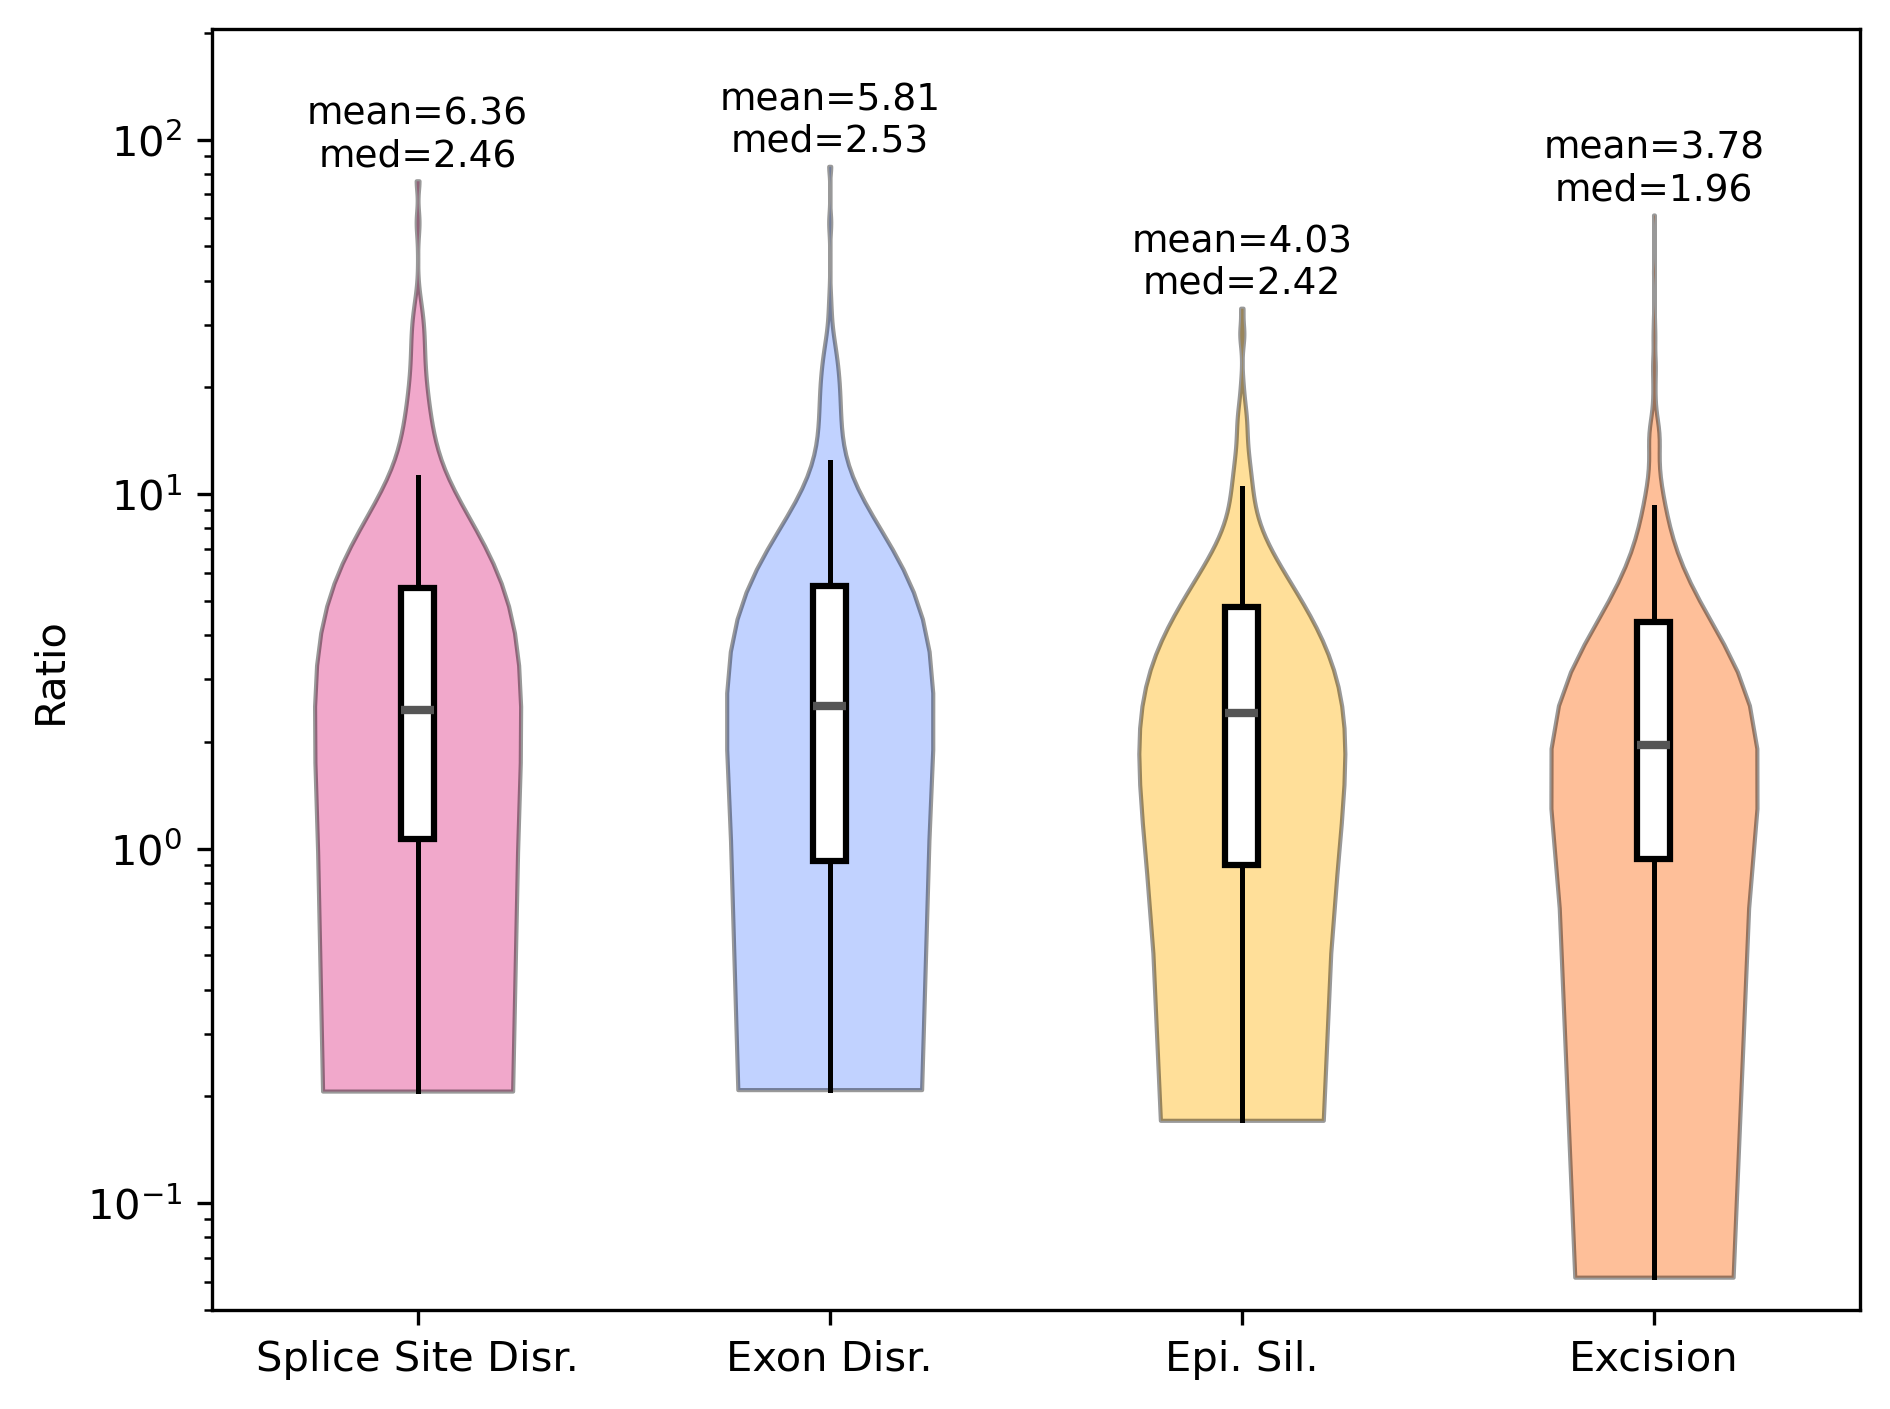

In [94]:
# get the information necessary for the ratios for each strategy
num_samples=2548
# data frame of the number of genes that have over 4 dominant pathogenic mutations
data_filt = data[['hgnc_symbol','dominant_mutation_count',
    'num_hets_preCas_exon_disr','num_hets_preCas_epi_sil','num_hets_preCas_ss_disr','num_hets_preCas_excision',
    'num_hets_exon_disr', 'num_hets_epi_sil','num_hets_ss_disr','num_hets_excision',
    'num_haplos_targeted_ag_exon_disr', 'num_haplos_targeted_ag_epi_sil','num_haplos_targeted_ag_ss_disr','num_haplos_targeted_ag_excision',
    'num_haplos_targeted_4g_exon_disr', 'num_haplos_targeted_4g_epi_sil', 'num_haplos_targeted_4g_ss_disr', 'num_haplos_targeted_4g_excision',
                 'num_hets_targeted_4g_exon_disr','num_hets_targeted_4g_epi_sil','num_hets_targeted_4g_ss_disr','num_hets_targeted_4g_excision']]
# replace zeroes with Nans
data_filt = data_filt.replace('Nan', np.nan)
# filter genes to those with over 4 dominant mutations
over4 = data_filt[data_filt['dominant_mutation_count']>4].drop_duplicates()
temp = over4[over4['num_hets_exon_disr']>0] # make sure we're only looking at targetable genes here
ma_indels = temp['num_hets_targeted_4g_exon_disr']
ms_indels = (4/temp['dominant_mutation_count'])*num_samples

temp = over4[over4['num_hets_epi_sil']>0]
ma_coff = temp['num_hets_targeted_4g_epi_sil']
ms_coff = (4/temp['dominant_mutation_count'])*num_samples

temp = over4[over4['num_hets_ss_disr']>0]
ma_be = temp['num_hets_targeted_4g_ss_disr']
ms_be = (4/temp['dominant_mutation_count'])*num_samples

temp = over4[over4['num_hets_excision']>0]
ma_ex = temp['num_hets_targeted_4g_excision']
ms_ex = (4/temp['dominant_mutation_count'])*num_samples

ratio_indels = ma_indels/ms_indels
ratio_coff = ma_coff/ms_coff
ratio_be = ma_be/ms_be
ratio_ex = ma_ex/ms_ex

# group all strategies' ratios into one vector
dv = [ratio_be, ratio_indels, ratio_coff, ratio_ex]

new_dv=[]
for item in dv:
    new_dv.append([x for x in item if x>0]) # remove any zeroes, as they cause the plot to look strange
dv=new_dv.copy()
fig, ax = plt.subplots()

# --- Violin plot (no min/max lines, no median) ---
parts = ax.violinplot(
    dv,
    showmedians=False,
    showextrema=False
)

# Custom colors (change these to whatever you prefer)
colors = ['#DC267F', '#648FFF', '#FFB000', '#FE6100']

for body, color in zip(parts['bodies'], colors):
    body.set_facecolor(color)
    body.set_edgecolor('black')
    body.set_alpha(0.4)

# --- Boxplot overlay (standard 1.5 IQR whiskers) ---
bp = ax.boxplot(
    dv,
    widths=0.08,
    patch_artist=True,
    showfliers=False,
    whis=1.5
)

# Style box
for box in bp['boxes']:
    box.set_facecolor('white')
    box.set_edgecolor('black')
    box.set_linewidth(1.5)

# Style whiskers
for whisker in bp['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(1.2)

# Remove caps
for cap in bp['caps']:
    cap.set_visible(False)

# Style median
for median in bp['medians']:
    median.set_color('#555555')
    median.set_linewidth(2)

# Axis labels
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Splice Site Disr.", "Exon Disr.", "Epi. Sil.", "Excision"])
ax.set_ylabel("Ratio")

# ---- Add mean & median text ----
for i, d in enumerate(dv, start=1):
    d = np.array(d)
    d = d[~np.isnan(d)]
    
    mean_val = np.mean(d)
    median_val = np.median(d)
    ymax = np.max(d)

    ax.text(
        i,
        ymax * 1.05,
        f"mean={mean_val:.2f}\nmed={median_val:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# # Increase y-axis height
ax.set_ylim(0.05, 205)

plt.yscale('log')
plt.tight_layout()
plt.show()